In [20]:
import kagglehub
from pathlib import Path

DATA_DIR = Path("./data")

# Download latest version
try:
    path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia", output_dir=str(DATA_DIR))
    print("Dataset path:", path)
except FileExistsError:
    print(".data/이 비어있지 않아서 다운로드를 건너뜁니다.")

.data/이 비어있지 않아서 다운로드를 건너뜁니다.


# 1. EDA

> 도표 원칙: 범주형 개수는 **Bar chart**, 연속값 분포는 **Histogram / Boxplot**, 두 연속값의 관계는 **Scatter**, 행렬형 개수는 **Heatmap**. 클래스·split 색상은 고정한다(NORMAL=파랑, PNEUMONIA=주황 / train=파랑, val=주황, test=초록).

1. **클래스 비율 확인**:
    - **목적: 데이터 클래스가 각 train/val/test 데이터셋에 고루 분포되어있는 지 확인하고, 데이터 전처리 시에 증강 기법 적용의 필요성을 검토한다.**
    - **목적: 모두 PNEUMONIA이라고 찍었을 때의 기준선을 확인한다.**
    - **목적: 모델 성능 평가 지표의 기준을 결정한다.**
    1. NORMAL과 PNEUMONIA 클래스 분포를 train/val/test 데이터셋에 대해서 절대 도수와 비율로 확인한다.
        - 활용 도표: DataFrame(count, ratio) + Grouped Bar chart(절대 도수) + 100% Stacked Bar chart(비율)
        - 함께 계산: 모두 PNEUMONIA로 예측했을 때의 accuracy / precision / recall / F1 기준선 표
    2. NORMAL과 PNEUMONIA 클래스 별로 실제 이미지를 train/val/test 데이터셋 내에서 직접 눈으로 확인한다.
        - 육안 확인 시에 순수한 갈비뼈 부분만 있는 게 아니라 목걸이, 심전도 전극선 등의 문제가 있는 지 확인한다.
        - 활용 도표: 실제 이미지 그리드(시드 고정 무작위 추출, 행=split×클래스, 열=이미지 8장). 아티팩트 탐색 목적이므로 5장보다 많이 본다.
        - 형식:

            | 데이터셋 | 클래스 | 이미지 1 | 이미지 2 | 이미지 3 | ... | 이미지 8 |
            | -- | -- | -- | -- | -- | -- | -- |
            | train | NORMAL | img1 | img2 | img3 | ... | img8 |
            | train | PNEUMONIA | img1 | img2 | img3 | ... | img8 |
            | val | NORMAL | img1 | img2 | img3 | ... | img8 |
            | val | PNEUMONIA | img1 | img2 | img3 | ... | img8 |
            | test | NORMAL | img1 | img2 | img3 | ... | img8 |
            | test | PNEUMONIA | img1 | img2 | img3 | ... | img8 |

2. **데이터 분할 비율 확인:**
    - **목적: val/test의 데이터 양이 충분히 확보되어있는 지 확인하고, 데이터 셋 재분할의 필요성을 검토한다.**
    - **목적: 데이터셋 재분할이 필요하다고 판단되면 재분할 비율과 그룹 기준까지 결정한다.**
    1. train/val/test에 분할되어있는 데이터 양의 절대 도수와 비율을 확인한다.
        - 활용 도표: DataFrame + Bar chart(절대 도수) + 100% Stacked Bar chart(비율). 범주가 3개뿐이므로 Histogram이 아니라 Bar chart를 쓴다.

3. **이미지 크기와 채널 확인:**
    - **목적: ImageNet으로 학습된 모델에 사진을 그대로 넣을 수 있을 지, 데이터 크기와 채널을 하나로 맞추는 전처리의 필요성, 후보와 trade-off를 검토한다.**
    - **목적: ImageNet은 3채널 픽셀 값이 다르다. X-ray는 흑백이다. ImageNet 통계와 데이터셋 자체 통계 중 무엇으로 정규화할 지 결정한다.**
    - **목적: 평활화 기법(CLAHE) 적용의 필요성을 검토한다.**
    1. 이미지 크기(width, height)와 가로세로 비율 분포를 train/val/test에 있는 모든 데이터에 대해서 확인한다.
        - 활용 도표: describe() 요약 DataFrame(split별 min/median/max) + width / height / aspect ratio 각각의 Histogram(hue=split) + width vs height Scatter(색=split). 연속값이므로 도수표 대신 요약 통계와 분포 도표를 쓴다.
    2. 클래스 별 크기 차이를 확인한다.
        - 활용 도표: 클래스별 중앙값 DataFrame + Boxplot(x=클래스, y=width / height / aspect ratio, hue=split) + width vs height Scatter(색=클래스). 크기가 클래스와 상관되면 모델이 "작으면 폐렴" 지름길을 배울 수 있다.
    3. 이미지 채널 분포를 train/val/test에 있는 모든 데이터에 대해서 절대 도수와 비율로 확인한다.
        - 활용 도표: crosstab DataFrame(split × 클래스 × 채널 mode) + Bar chart. 채널 수는 1 또는 3의 이산값이므로 Bar chart를 쓴다.
    4. 채널이 여러개인 경우, 채널별로 픽셀값이 같은 지 다른 지를 확인한다. 한 채널로 합칠 수 있을 지 확인한다.
        - 활용 도표: DataFrame(RGB 이미지별 max|R−G|, max|G−B|, 세 채널 완전동일 여부 집계) + 예시 이미지 1장의 R / G / B / |R−G| 차이맵 4분할 패널
    5. 이미지 단위 밝기 평균과 표준편차 분포를 확인한다. CLAHE 적용 근거를 검토한다.
        - 활용 도표: 이미지별 std Histogram(hue=클래스) + mean vs std Scatter(색=클래스, 마커=저장 모드) + 세부 유형(NORMAL/bacteria/virus)×저장 모드별 std DataFrame + 저대비 이미지 CLAHE 전후 좌우 비교 + CLAHE 전후 std Histogram과 요약 DataFrame
        - CLAHE 판단 절차: (a) 저대비 꼬리가 있는가, (b) 저대비의 일부가 병변이 아닌 촬영·저장 조건(노출 극단, RGB 저장 경로)에서 오는가, (c) 저대비 이미지에 CLAHE를 적용하면 폐 구조가 살아나는가(육안), (d) CLAHE가 병변 신호(세균성 폐렴의 전역적 음영)까지 지우거나 노이즈를 키우는 부작용이 있는가. 클래스 간 std 차이의 증감만으로는 편향 제거와 신호 손실을 구분할 수 없으므로, 최종 결정은 전처리 변형(없음/CLAHE) 학습 실험과 Grad-CAM으로 내린다.
    6. Resize와 채널 통일을 하는 경우 이미지가 변한 예시를 육안으로 확인한다.
        - 활용 도표: 후보 전략별 좌우 비교 이미지(원본 | 224×224 늘리기 | 짧은 변 224 후 center crop | 비율 유지 padding) + RGB→L 변환 전후 비교

4. **이미지 상세 분석:**
    - **목적: 데이터 정규화의 기준을 수립한다.**
    1. NORMAL과 PNEUMONIA 클래스 각각의 픽셀 밝기 분포를 확인한다.
        - 활용 도표: 픽셀 단위 밝기 Histogram 오버레이(NORMAL vs PNEUMONIA, 전체 픽셀 집계) + 이미지별 mean Boxplot(x=클래스, hue=split) + 클래스별 평균 이미지(mean image)와 그 차이맵(위치 편향 확인)
    2. 학습 대상 데이터와 사전학습 데이터(ImageNet)를 픽셀 밝기 평균, std를 비교한다.
        - 활용 도표: 비교 DataFrame(데이터셋 mean/std vs ImageNet mean/std) + 실제 픽셀 Histogram 위에 두 통계의 mean 수직선과 ±std 음영 밴드 오버레이 + 두 정규화를 각각 적용한 뒤의 값 분포 비교. X-ray 픽셀 분포는 정규분포가 아니라 쌍봉이므로 Bell curve로 그리지 않는다.

5. **중복 이미지 점검:**
    - **목적: train/val/test에 완전히 중복되는 이미지가 있는 지 확인하고, 중복제거 기준을 수립한다**
    1. train과 val, test에 해시 기준 완전히 중복되는 이미지가 있는 지 확인한다.
        - 활용 도표: 3×3 Heatmap(행=split, 열=split, 값=중복 쌍 수; split 간=누수, split 내=단순 중복) + 중복 그룹 DataFrame + 중복 쌍 좌우 비교 이미지

6. **중복 환자 점검:**
    - **목적: train/val/test에 동일한 환자의 X-ray 사진이 나뉘어 들어가면 데이터 누수의 위험이 있을 수 있다. 이 위험성이 실재하는 지 점검한다.**
    1. train 내 사람별 이미지 수 분포를 확인한다.
        - 활용 도표: Bar chart(x=한 사람당 이미지 수, y=사람 수) + 상위 N명 DataFrame(bacteria/virus 내역 포함). 이산값이므로 Histogram 대신 Bar chart를 쓴다.
    2. train/test 번호 체계가 독립적이라는 근거, NORMAL에는 person 정보가 없다는 점을 확인한다.
        - 활용 도표: 파일명 패턴 DataFrame(split × 클래스별 패턴과 개수) + person id 집합 교집합 DataFrame(split 쌍별) + Strip plot(x=person id, y=split). 번호가 겹치는 경우 5-1의 해시 중복 결과와 교차 확인한다.

## 1-0. EDA 공통 준비
- 전체 이미지를 한 번만 스캔해서 크기·채널·해시·밝기 통계·클래스별 픽셀 히스토그램을 `eda_cache/`에 캐시한다.
- 이후 모든 EDA 셀은 `meta`(DataFrame)와 `PIX_HIST`(dict)만 사용한다.
- 차트 텍스트는 환경별 한글 폰트 문제를 피하기 위해 영문으로 둔다.

In [ ]:
import hashlib
import random
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

DATA_DIR = Path("./data")
CACHE_DIR = Path("./eda_cache")
CACHE_DIR.mkdir(exist_ok=True)
SPLITS = ["train", "val", "test"]
CLASSES = ["NORMAL", "PNEUMONIA"]
SEED = 42
IMG_SIZE = 224
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])

# 고정 색상: 범주 순서 고정, 순환 없음
CLASS_COLORS = {"NORMAL": "#2a78d6", "PNEUMONIA": "#eb6834"}
SPLIT_COLORS = {"train": "#2a78d6", "val": "#eb6834", "test": "#1baf7a"}
SEQ_CMAP = "Blues"  # 순차(크기) 색상: 단일 색조

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 11,
    "axes.unicode_minus": False,
})

PERSON_RE = re.compile(r"person(\d+)_(bacteria|virus)_(\d+)")


def _parse_name(name: str):
    m = PERSON_RE.match(name)
    if m:
        return int(m.group(1)), m.group(2), int(m.group(3))
    return None, None, None


def scan_images(force: bool = False):
    """모든 이미지를 1회 디코딩해 메타데이터 DataFrame과 클래스별 픽셀 히스토그램을 만든다."""
    meta_path = CACHE_DIR / "image_meta.csv"
    hist_path = CACHE_DIR / "pixel_hist.npz"
    if meta_path.exists() and hist_path.exists() and not force:
        return pd.read_csv(meta_path), dict(np.load(hist_path))

    rows = []
    hists = {f"{s}/{c}": np.zeros(256, dtype=np.int64) for s in SPLITS for c in CLASSES}
    for split in SPLITS:
        for cls in CLASSES:
            paths = sorted((DATA_DIR / split / cls).glob("*.jpeg"))
            for p in paths:
                with Image.open(p) as im:
                    mode, (w, h) = im.mode, im.size
                    arr = np.asarray(im)
                    gray = np.asarray(im.convert("L"))
                if arr.ndim == 3:
                    a16 = arr.astype(np.int16)
                    ch_max_diff = int(max(np.abs(a16[..., 0] - a16[..., 1]).max(),
                                          np.abs(a16[..., 1] - a16[..., 2]).max()))
                    n_channels = arr.shape[2]
                else:
                    ch_max_diff, n_channels = 0, 1
                person_id, pneu_type, seq = _parse_name(p.name)
                rows.append({
                    "split": split, "cls": cls, "path": str(p), "filename": p.name,
                    "width": w, "height": h, "aspect": w / h,
                    "mode": mode, "n_channels": n_channels, "ch_max_diff": ch_max_diff,
                    "file_md5": hashlib.md5(p.read_bytes()).hexdigest(),
                    "pixel_md5": hashlib.md5(gray.tobytes()).hexdigest(),
                    "img_mean": float(gray.mean() / 255.0),
                    "img_std": float(gray.std() / 255.0),
                    "person_id": person_id, "pneu_type": pneu_type, "seq": seq,
                })
                hists[f"{split}/{cls}"] += np.bincount(gray.ravel(), minlength=256)
            print(f"scanned {split:5s}/{cls:9s}: {len(paths):5d} images")
    if not rows:
        raise FileNotFoundError(f"no images found under {DATA_DIR.resolve()} - check DATA_DIR")
    meta = pd.DataFrame(rows)
    meta.to_csv(meta_path, index=False)
    np.savez(hist_path, **hists)
    return meta, hists


meta, PIX_HIST = scan_images()
meta["split"] = pd.Categorical(meta["split"], SPLITS, ordered=True)
meta["cls"] = pd.Categorical(meta["cls"], CLASSES, ordered=True)
print(meta.shape)
meta.head()


(5856, 17)


,split,cls,path,filename,width,height,aspect,mode,n_channels,ch_max_diff,file_md5,pixel_md5,img_mean,img_std,person_id,pneu_type,seq
0,train,NORMAL,data/train/NORMAL/IM-0115-0001.jpeg,IM-0115-0001.jpeg,2090,1858,1.124865,L,1,0,20e1b8286b2d4e7a9869d42abd1cbf91,aa9eda99926e3333a7207b427f12c01f,0.505520,0.244318,NaN,NaN,NaN
1,train,NORMAL,data/train/NORMAL/IM-0117-0001.jpeg,IM-0117-0001.jpeg,1422,1152,1.234375,L,1,0,9299d3c610ad02c31c30469c9a4c2431,b4dd939f77289c6079a339e8737fbdac,0.394708,0.234543,NaN,NaN,NaN
2,train,NORMAL,data/train/NORMAL/IM-0119-0001.jpeg,IM-0119-0001.jpeg,1810,1434,1.262204,L,1,0,4b873c9f031149dccd93d51e092215ca,74a2e2b7f93e7349d1390260c0afef86,0.478320,0.270025,NaN,NaN,NaN
3,train,NORMAL,data/train/NORMAL/IM-0122-0001.jpeg,IM-0122-0001.jpeg,1618,1279,1.265051,L,1,0,f510c0d0ff70e725449ecbdf93553a70,675cc7febd167ab9d3f45db07da6041d,0.521514,0.254787,NaN,NaN,NaN
4,train,NORMAL,data/train/NORMAL/IM-0125-0001.jpeg,IM-0125-0001.jpeg,1600,1125,1.422222,L,1,0,3c0c7a39407e411aa83b854f8f8fa8f0,1473005010ef56a52fe25305f7e92e7d,0.416568,0.255250,NaN,NaN,NaN


## 1-1. 클래스 분포: 절대 도수와 비율
- 활용 도표: DataFrame + Grouped Bar(절대 도수) + 100% Stacked Bar(비율)
- 함께 확인: 모두 PNEUMONIA로 예측했을 때의 기준선(accuracy / precision / recall / F1)

- **분석 결과**
    - train+val
        - NORMAL : PNEUMONIA ≈ 3:7 
    - test
        - NORMAL : PNEUMONIA ≈ 0.4:0.6
    - 클래스 불균형이 심하다. 
    - train+val 데이터셋에 대해서  NORMAL 클래스를 증강하여 비율을 비슷하게 맞춰야 한다. 
    - test 데이터셋은 괜찮다. 

count            ratio          
cls   NORMAL PNEUMONIA NORMAL PNEUMONIA
split                                  
train   1341      3875  0.257     0.743
val        8         8  0.500     0.500
test     234       390  0.375     0.625

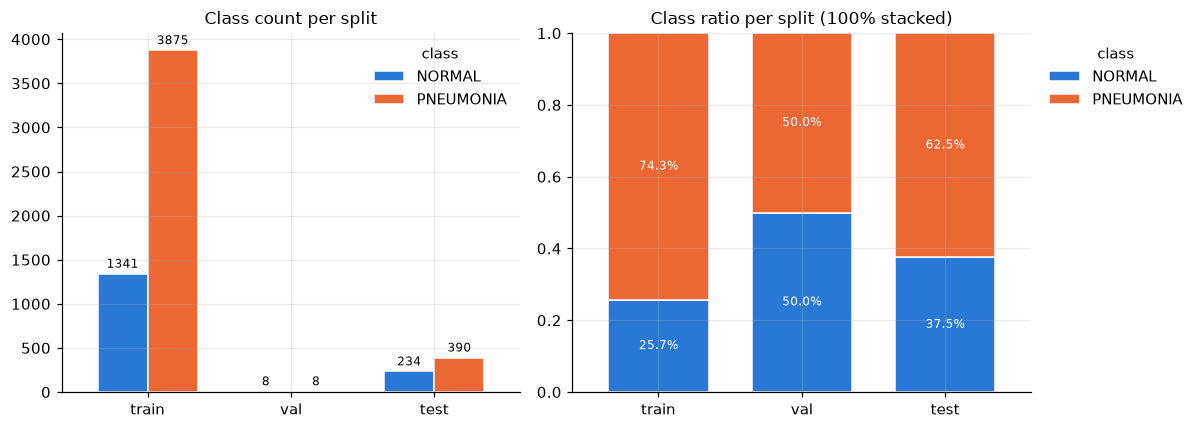

Baseline: predict all as PNEUMONIA


,accuracy,precision,recall,f1
split,,,,
train,0.743,0.743,1.0,0.852
val,0.500,0.500,1.0,0.667
test,0.625,0.625,1.0,0.769


In [5]:
ct = pd.crosstab(meta["split"], meta["cls"]).reindex(index=SPLITS, columns=CLASSES)
ratio = ct.div(ct.sum(axis=1), axis=0)
display(pd.concat({"count": ct, "ratio": ratio.round(3)}, axis=1))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ct.plot.bar(ax=axes[0], color=[CLASS_COLORS[c] for c in CLASSES], width=0.7, edgecolor="white", rot=0)
for bars in axes[0].containers:
    axes[0].bar_label(bars, fontsize=8, padding=2)
axes[0].set_title("Class count per split")
axes[0].set_xlabel("")
axes[0].legend(title="class", frameon=False)

ratio.plot.bar(ax=axes[1], stacked=True, color=[CLASS_COLORS[c] for c in CLASSES],
               width=0.7, edgecolor="white", rot=0)
for bars in axes[1].containers:
    axes[1].bar_label(bars, labels=[f"{v:.1%}" for v in bars.datavalues],
                      label_type="center", fontsize=8, color="white")
axes[1].set_ylim(0, 1)
axes[1].set_title("Class ratio per split (100% stacked)")
axes[1].set_xlabel("")
axes[1].legend(title="class", frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

# 기준선: 모든 샘플을 PNEUMONIA(positive)로 예측
pos = ratio["PNEUMONIA"]
baseline = pd.DataFrame({
    "accuracy": pos,
    "precision": pos,
    "recall": 1.0,
    "f1": 2 * pos / (1 + pos),
}).round(3)
print("Baseline: predict all as PNEUMONIA")
display(baseline)


## 1-2. 실제 이미지 육안 확인
- 활용 도표: 이미지 그리드(행=split×클래스, 열=시드 고정 무작위 8장)
- 확인 포인트: 목걸이, 심전도 전극선, 텍스트 마커, 회전/뒤집힘, 크롭 범위

- **분석 결과**
    - 사진 자체에 L/R 좌우 등 표기가 있음.
    - 심전도 선 등 의료장비로 추측되는 선이 보임. 
    - 갈비뼈 부분을 crop할 필요가 있다. 
    - **crop 범위를 정하는 것은 과제다. //TODO**

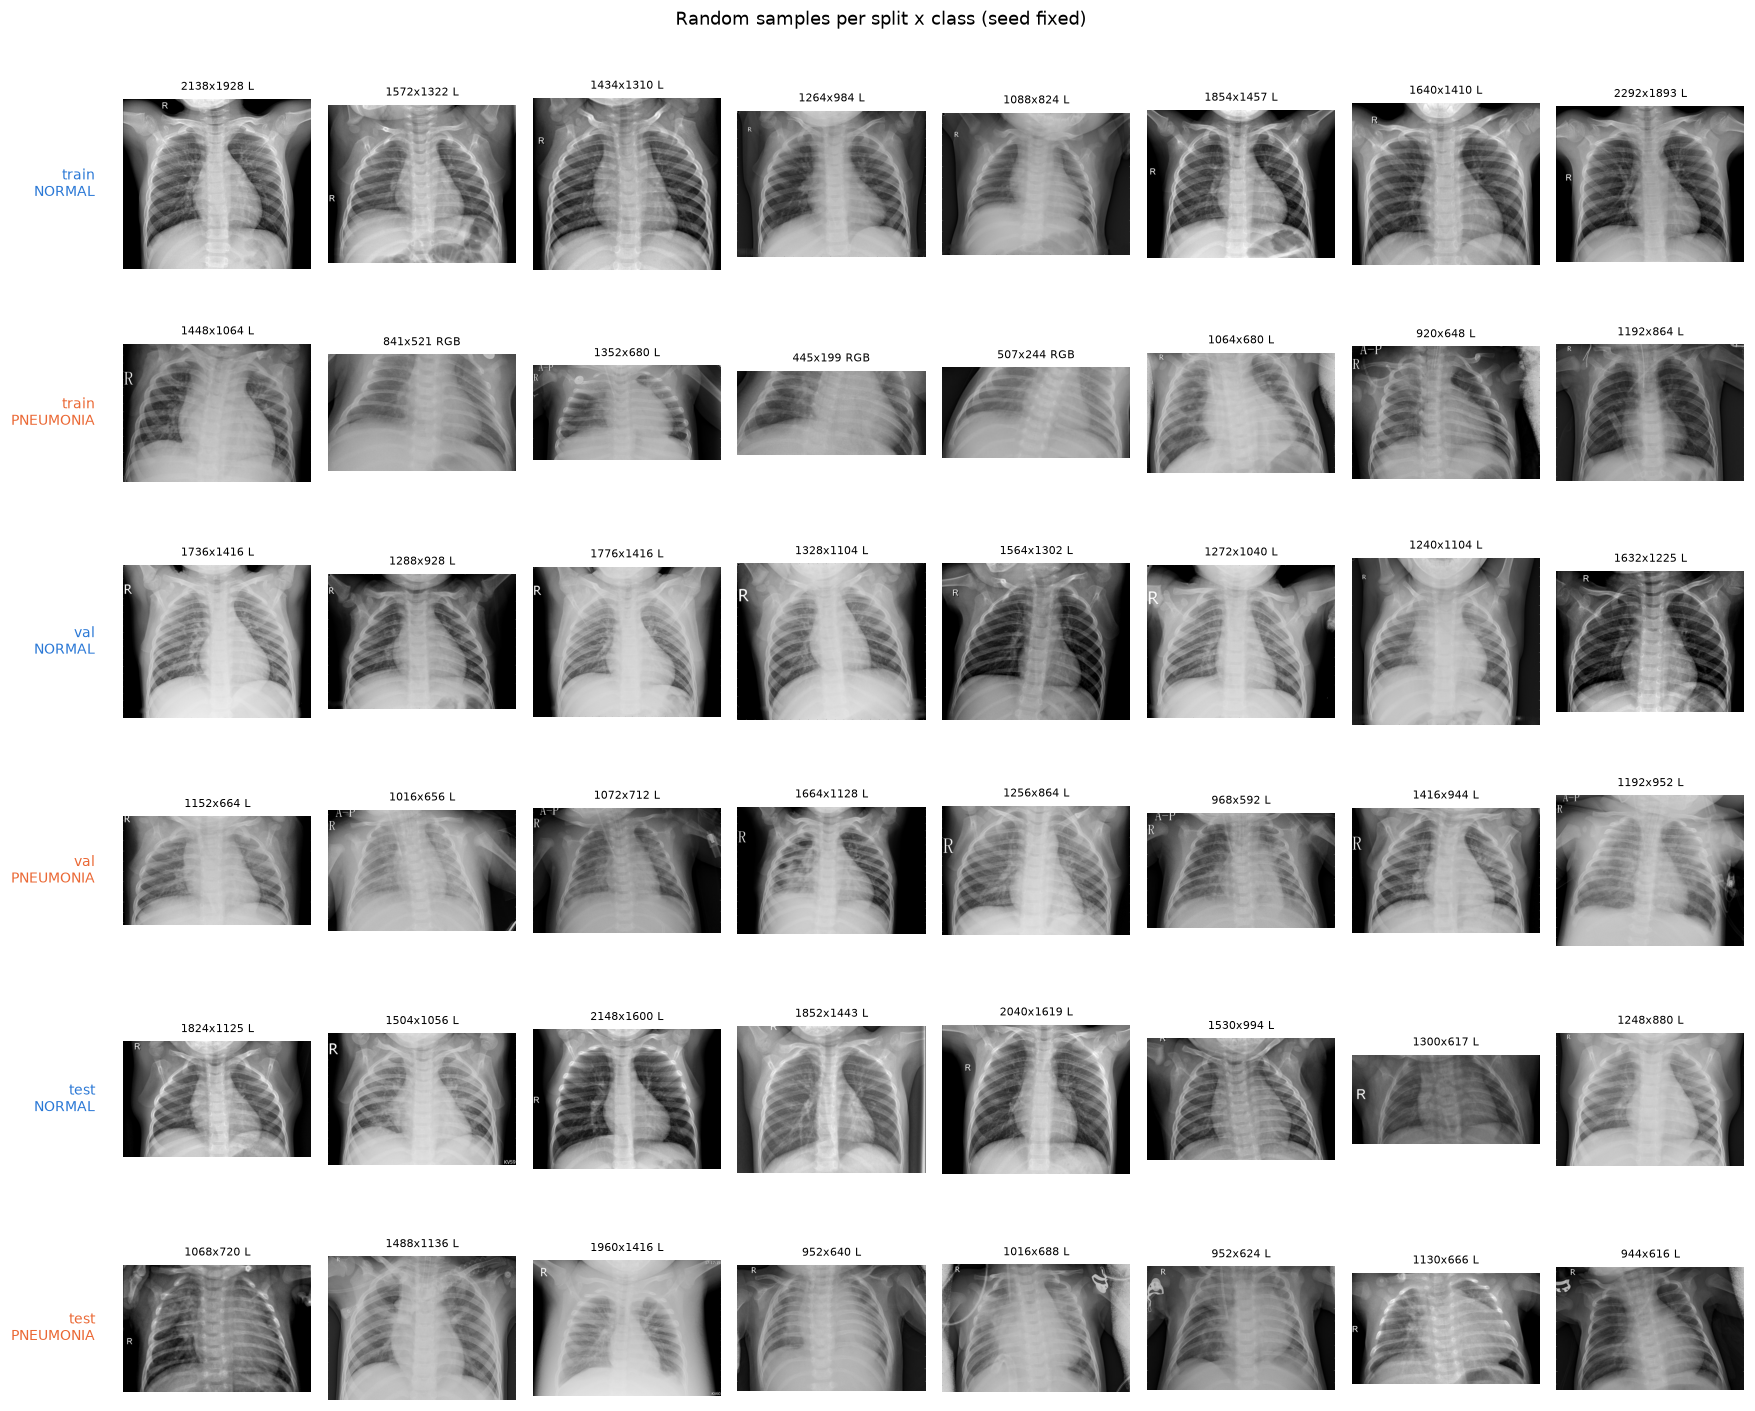

In [6]:
N_SAMPLES = 8
rng = random.Random(SEED)

fig, axes = plt.subplots(len(SPLITS) * len(CLASSES), N_SAMPLES,
                         figsize=(N_SAMPLES * 2.0, len(SPLITS) * len(CLASSES) * 2.2))
for r, (split, cls) in enumerate([(s, c) for s in SPLITS for c in CLASSES]):
    sub = meta[(meta["split"] == split) & (meta["cls"] == cls)]
    picks = sub.sample(n=min(N_SAMPLES, len(sub)), random_state=rng.randint(0, 10_000))
    for c_idx, ax in enumerate(axes[r]):
        ax.axis("off")
        if c_idx >= len(picks):
            continue
        row = picks.iloc[c_idx]
        with Image.open(row["path"]) as im:
            ax.imshow(im.convert("L"), cmap="gray", vmin=0, vmax=255)
        ax.set_title(f"{row['width']}x{row['height']} {row['mode']}", fontsize=7)
    axes[r][0].text(-0.15, 0.5, f"{split}\n{cls}", transform=axes[r][0].transAxes,
                    ha="right", va="center", fontsize=9, color=CLASS_COLORS[cls])
plt.suptitle("Random samples per split x class (seed fixed)", y=1.0)
plt.tight_layout()
plt.show()


## 2-1. 데이터 분할 비율
- 활용 도표: DataFrame + Bar chart(절대 도수) + 100% Stacked Bar(비율)
- 판단 포인트: val이 극단적으로 작으면 재분할이 필요하다.

- **분석 결과**
    - validation이 너무 적다. train과 validation을 합치고, 9:1 비율로 재분할한다. 
    - 9:1 비율의 근거: train+val : test ≈ 9:1.

,count,ratio
split,,
train,5216,0.8907
val,16,0.0027
test,624,0.1066


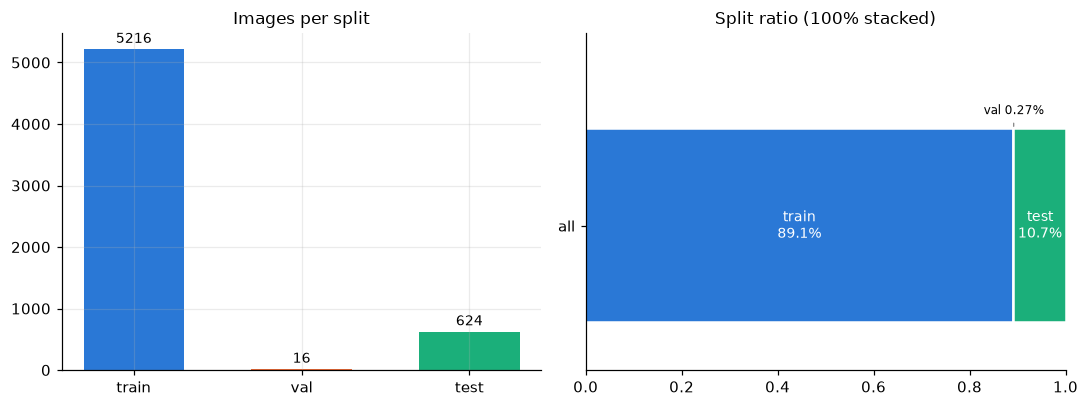

In [7]:
split_ct = meta["split"].value_counts().reindex(SPLITS)
split_df = pd.DataFrame({"count": split_ct, "ratio": (split_ct / split_ct.sum()).round(4)})
display(split_df)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
bars = axes[0].bar(SPLITS, split_ct.values, color=[SPLIT_COLORS[s] for s in SPLITS], width=0.6)
axes[0].bar_label(bars, padding=2, fontsize=9)
axes[0].set_title("Images per split")

left = 0
for s in SPLITS:
    v = split_df.loc[s, "ratio"]
    axes[1].barh(["all"], [v], left=left, color=SPLIT_COLORS[s], label=s, edgecolor="white")
    if v > 0.03:
        axes[1].text(left + v / 2, 0, f"{s}\n{v:.1%}", ha="center", va="center", color="white", fontsize=9)
    else:
        axes[1].annotate(f"{s} {v:.2%}", (left + v / 2, 0.4), xytext=(0, 10), textcoords="offset points",
                         ha="center", fontsize=8, arrowprops={"arrowstyle": "-", "color": "gray", "lw": 0.8})
    left += v
axes[1].set_xlim(0, 1)
axes[1].set_ylim(-0.6, 0.8)
axes[1].set_title("Split ratio (100% stacked)")
axes[1].grid(False)
plt.tight_layout()
plt.show()


## 3-1. 이미지 크기·가로세로 비율 분포 (split 기준)
- 활용 도표: describe() DataFrame + width / height / aspect(종횡비. 가로:세로) Histogram(hue=split) + width vs height Scatter(색=split)

- **분석결과**
    - 대부분의 경우 전체의 5%만이 height > width. 
    - 95% 이상이 width > height.
    - ***종횡비는 train, test에 걸쳐서 비슷하다. 종횡비의 차이는 없었다.***
    - 데이터 전처리 시 **종횡비 때문에 split을 다시 해야 할 필요는 없다.**
    - validation은 샘플 개수 16개로, 너무 적어서 bell shape이 아니라 튀는 모습이 보인다. 무시해도 된다. 


split         train      val     test
width  min   384.00   968.00   728.00
       5%    840.00  1004.00   889.20
       50%  1284.00  1280.00  1265.00
       95%  1928.00  1746.00  2224.50
       max  2916.00  1776.00  2752.00
height min   127.00   592.00   344.00
       5%    504.00   640.00   537.20
       50%   888.00   996.00   870.50
       95%  1670.00  1416.00  1914.65
       max  2663.00  1416.00  2713.00
aspect min     0.84     1.12     0.93
       5%      1.10     1.18     1.13
       50%     1.41     1.36     1.45
       95%     1.87     1.66     1.86
       max     3.38     1.73     2.58

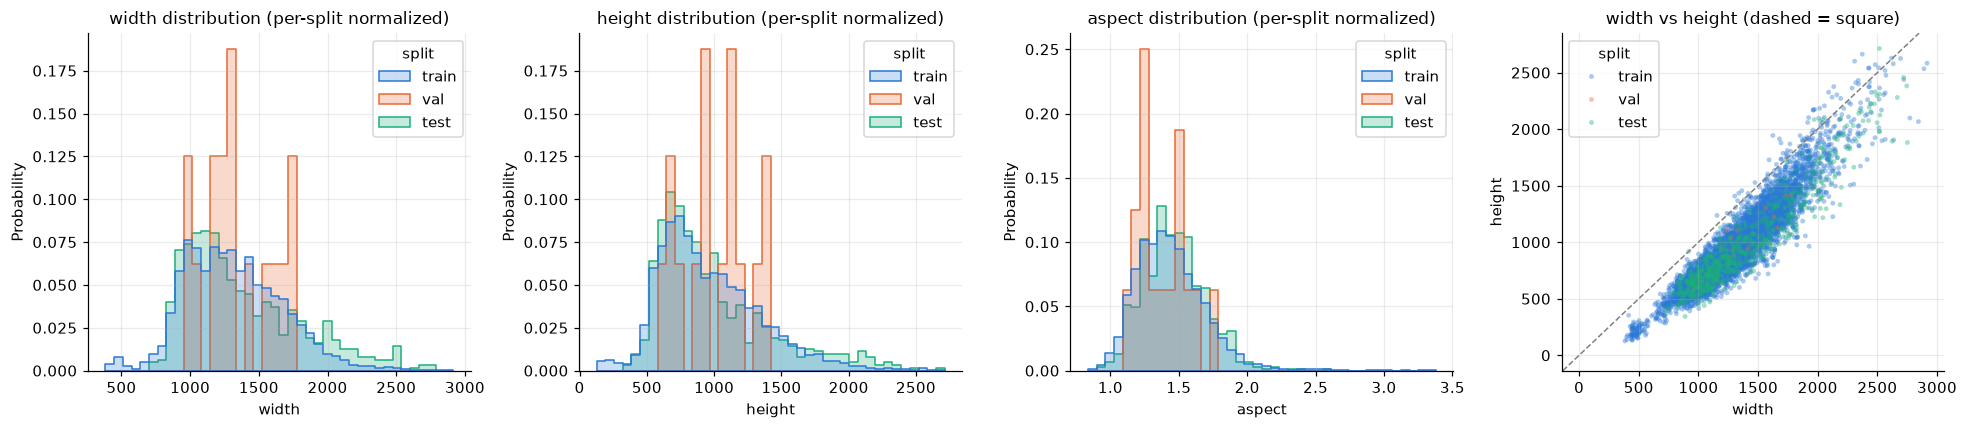

IMG_SIZE=224: 모든 이미지가 이보다 크다 -> False


In [8]:
size_cols = ["width", "height", "aspect"]
desc = (meta.groupby("split", observed=True)[size_cols]
        .describe(percentiles=[0.05, 0.5, 0.95])
        .loc[:, (slice(None), ["min", "5%", "50%", "95%", "max"])]
        .round(2))
display(desc.T)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes[:3], size_cols):
    sns.histplot(data=meta, x=col, hue="split", hue_order=SPLITS, palette=SPLIT_COLORS,
                 element="step", stat="probability", common_norm=False, bins=40, ax=ax, alpha=0.25)
    ax.set_title(f"{col} distribution (per-split normalized)")
sns.scatterplot(data=meta, x="width", y="height", hue="split", hue_order=SPLITS, palette=SPLIT_COLORS,
                s=10, alpha=0.4, linewidth=0, ax=axes[3])
axes[3].axline((0, 0), slope=1, color="gray", lw=1, ls="--")
axes[3].set_title("width vs height (dashed = square)")
plt.tight_layout()
plt.show()
print(f"IMG_SIZE={IMG_SIZE}: 모든 이미지가 이보다 크다 ->", bool((meta[["width", "height"]].min(axis=1) >= IMG_SIZE).all()))


## 3-2. 클래스별 크기 차이
- 활용 도표: 클래스별 중앙값 DataFrame + Boxplot(x=클래스, y=width / height / aspect, hue=split) + width vs height Scatter(색=클래스)
- 판단 포인트: 크기가 클래스와 상관되면 '작으면 폐렴' 지름길 학습 위험이 있다. 비율 유지 resize/crop 전략의 근거가 된다.

- **분석결과**
    - **PNEUMONIA**가 NORMAL에 비해 **종횡비가 크다.**
    - **PNEUMONIA**가 NORMAL에 비해 width도 작고, height도 더 작다. 즉, **크기가 더 작다.**
    - Resize/Crop을 하지 않는 경우, 이미지의 특징이 아니라 **크기를 근거로 예측할 위험이 있다.** 
    - 클래스 별로 크기/비율 차이가 크게 난다. ***Resize/Crop을 꼭 해야한다.*** 

width  height  aspect
split cls                              
train NORMAL     1640.0  1328.0    1.22
      PNEUMONIA  1168.0   776.0    1.49
val   NORMAL     1446.0  1164.5    1.22
      PNEUMONIA  1172.0   788.0    1.50
test  NORMAL     1762.0  1317.5    1.35
      PNEUMONIA  1111.0   736.0    1.51

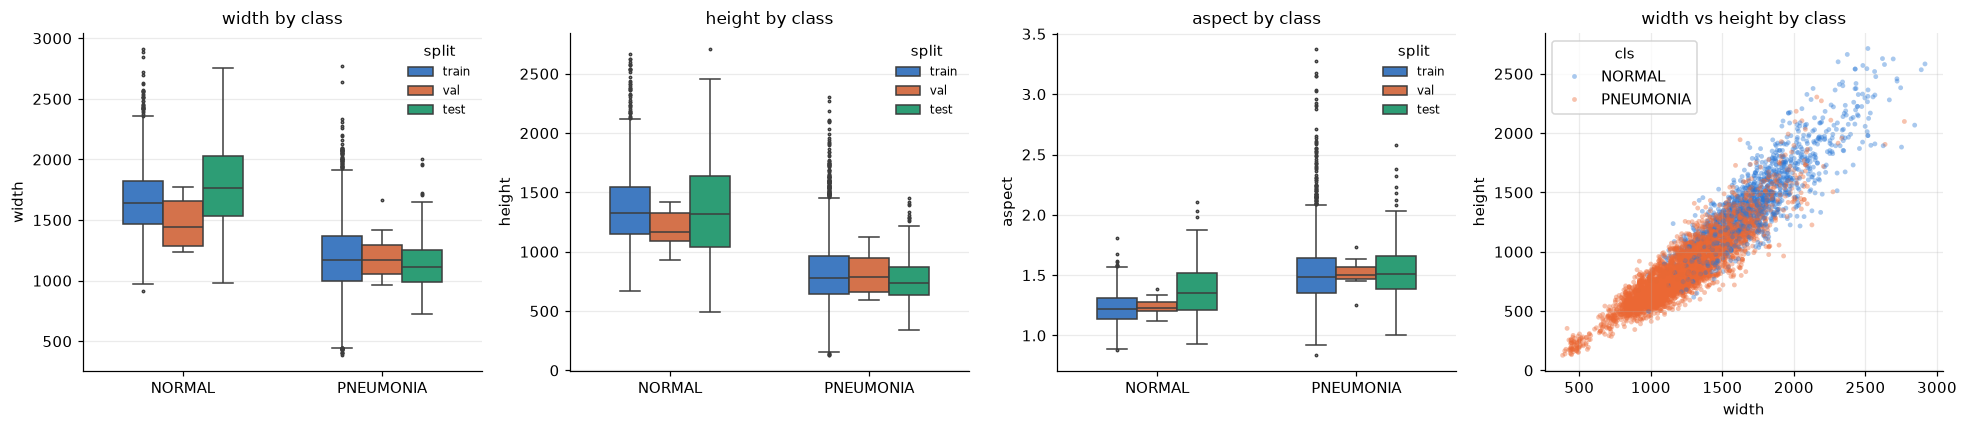

In [9]:
display(meta.groupby(["split", "cls"], observed=True)[size_cols].median().round(2))

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes[:3], size_cols):
    sns.boxplot(data=meta, x="cls", y=col, hue="split", order=CLASSES, hue_order=SPLITS,
                palette=SPLIT_COLORS, width=0.6, fliersize=1.5, linewidth=1, ax=ax)
    ax.set_title(f"{col} by class")
    ax.set_xlabel("")
    ax.legend(title="split", frameon=False, fontsize=8)
sns.scatterplot(data=meta, x="width", y="height", hue="cls", hue_order=CLASSES, palette=CLASS_COLORS,
                s=10, alpha=0.4, linewidth=0, ax=axes[3])
axes[3].set_title("width vs height by class")
plt.tight_layout()
plt.show()


## 3-3. 채널 분포
- 활용 도표: crosstab DataFrame(split × 클래스 × mode) + Bar chart
- 판단 포인트: 특정 클래스에만 RGB가 있으면 채널 수 자체가 클래스 단서가 되므로 반드시 통일해야 한다.

- **분석 결과**
    - train에서 RGB 채널을 갖고있는 데이터가 PNEUMONIA 클래스에만 100% 몰려있다. 
    - 모든 split에서 NORMAL은 모두 채널이 1개다.
    - **따라서 채널을 통일하지 않으면 모델이 채널이 3개라는 이유로 PNEUMONIA클래스라고 예측할 위험이 있다.**
    - ***채널을 1개 또는 3개로 무조건 통일해야 한다.***

count       ratio       
mode                L  RGB      L    RGB
split cls                               
train NORMAL     1341    0  1.000  0.000
      PNEUMONIA  3592  283  0.927  0.073
val   NORMAL        8    0  1.000  0.000
      PNEUMONIA     8    0  1.000  0.000
test  NORMAL      234    0  1.000  0.000
      PNEUMONIA   390    0  1.000  0.000

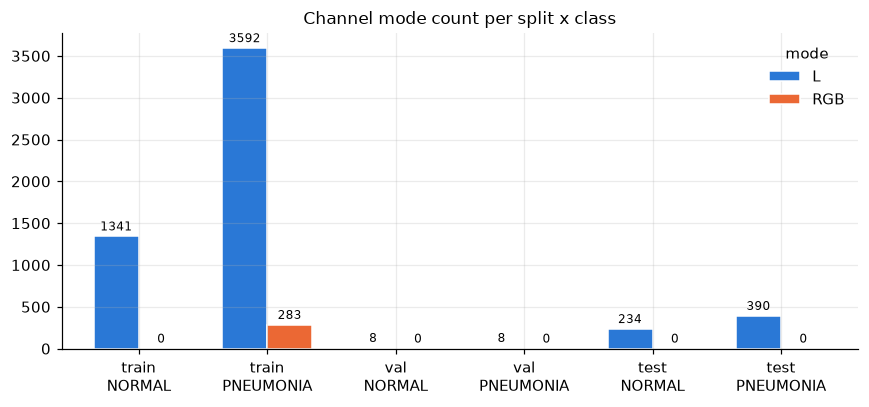

In [10]:
mode_ct = pd.crosstab([meta["split"], meta["cls"]], meta["mode"])
mode_ratio = mode_ct.div(mode_ct.sum(axis=1), axis=0).round(4)
display(pd.concat({"count": mode_ct, "ratio": mode_ratio}, axis=1))

modes = list(mode_ct.columns)
mode_colors = {m: c for m, c in zip(modes, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"])}
fig, ax = plt.subplots(figsize=(8, 3.8))
mode_ct.plot.bar(ax=ax, color=[mode_colors[m] for m in modes], width=0.7, edgecolor="white", rot=0)
for bars in ax.containers:
    ax.bar_label(bars, fontsize=8, padding=2)
ax.set_title("Channel mode count per split x class")
ax.set_xticklabels([f"{s}\n{c}" for s, c in mode_ct.index])
ax.set_xlabel("")
ax.legend(title="mode", frameon=False)
plt.tight_layout()
plt.show()


## 3-4. 다채널 이미지의 채널 간 픽셀값 동일 여부
- 활용 도표: DataFrame(RGB 이미지별 max|R−G| / max|G−B| 집계, 완전 동일 여부) + 예시 R / G / B / |R−G| 4분할 패널
- 판단 포인트: 채널이 완전히 같으면 정보 손실 없이 1채널로 합칠 수 있다.

- **분석 결과**
    - 세 개 채널의 값이 완전히 동일하다. 
    - ***3채널을 1채널로 합치거나, 1채널을 3채널로 복사해서 확장할 수 있다.*** 

multi-channel images: 283 / 5856


,,n,all_equal,diff_max,diff_median
split,cls,,,,
train,PNEUMONIA,283,283,0,0.0


,count,mean,std,min,25%,50%,75%,max
ch_max_diff,283.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


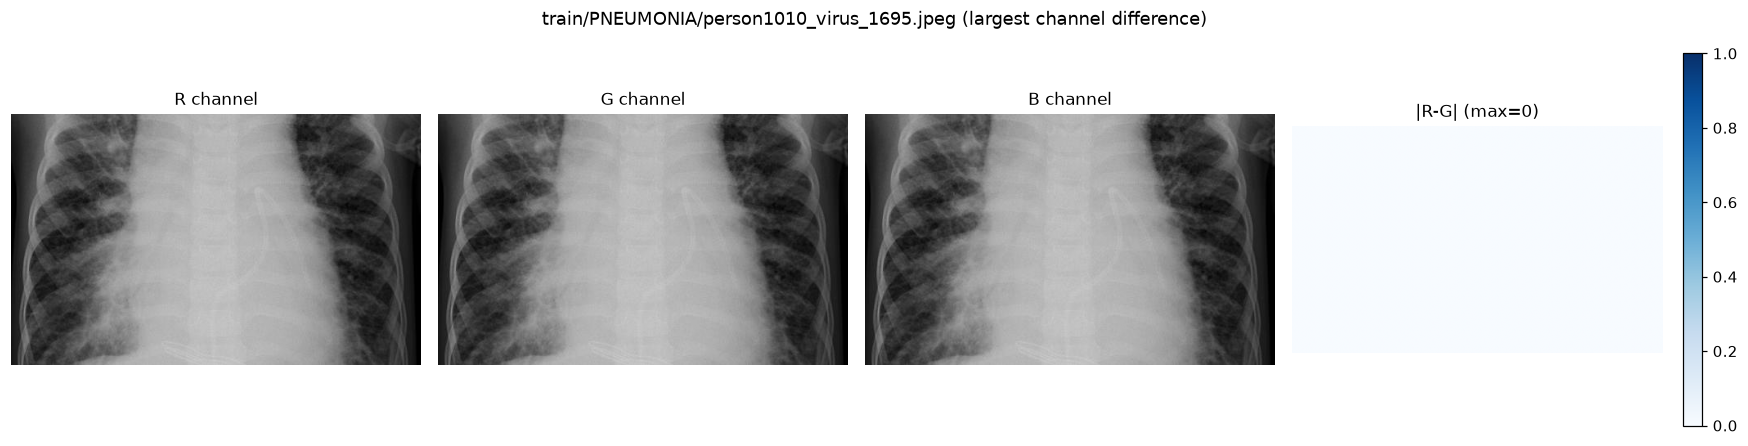

In [11]:
rgb = meta[meta["n_channels"] == 3]
print(f"multi-channel images: {len(rgb)} / {len(meta)}")
if len(rgb):
    summary = (rgb.assign(all_equal=rgb["ch_max_diff"] == 0)
               .groupby(["split", "cls"], observed=True)
               .agg(n=("path", "size"), all_equal=("all_equal", "sum"),
                    diff_max=("ch_max_diff", "max"), diff_median=("ch_max_diff", "median")))
    display(summary)
    display(rgb["ch_max_diff"].describe().to_frame("ch_max_diff").T)

    ex = rgb.sort_values("ch_max_diff", ascending=False).iloc[0]
    with Image.open(ex["path"]) as im:
        arr = np.asarray(im).astype(np.int16)
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for i, name in enumerate("RGB"):
        axes[i].imshow(arr[..., i], cmap="gray", vmin=0, vmax=255)
        axes[i].set_title(f"{name} channel")
    diff = np.abs(arr[..., 0] - arr[..., 1])
    im_ = axes[3].imshow(diff, cmap=SEQ_CMAP, vmin=0, vmax=max(1, diff.max()))
    axes[3].set_title(f"|R-G| (max={diff.max()})")
    plt.colorbar(im_, ax=axes[3], fraction=0.046)
    for ax in axes:
        ax.axis("off")
    plt.suptitle(f"{ex['split']}/{ex['cls']}/{ex['filename']} (largest channel difference)")
    plt.tight_layout()
    plt.show()


## 3-5. 이미지 단위 밝기 평균·표준편차 분포와 CLAHE 검토

- 활용 도표
    - 데이터프레임 표: [표 1] 클래스별 img_mean/img_std 요약 · [표 2] 저대비 이미지의 split×클래스 분포 · [표 3] 세부 유형(NORMAL/bacteria/virus)×저장 모드(L/RGB)별 std · [표 4] CLAHE 전후 std 요약
    - 시각화된 장표: [장표 1] 클래스별 std Histogram + mean vs std Scatter(색=클래스, 마커=저장 모드) · [장표 2] 저대비 이미지 원본 | CLAHE | 픽셀 히스토그램 · [장표 3] CLAHE 전후 std Histogram(hue=클래스)
    - 저대비 기준: 전체 이미지의 img_std 하위 5% (0.161 이하, 293장)

- 이미지 단위 밝기의 mean, std는 **한 이미지의 평균 밝기와, 그 이미지가 뿌연 정도를 의미한다**
    - mean이 높다 == 이미지 전체적인 노출(exposure)이 높다. 밝아보인다.
    - std가 높다 == 이미지 전체적으로 대비(contrast)가 높다. 뼈와 폐가 뚜렷이 갈린다.

    - mean 높고 std 낮다 == 이미지가 전체적으로 밝게 뿌옇다.
    - mean 높고 std 높다 == 이미지가 전체적으로 밝지만 구분은 잘 된다.
    - mean 낮고 std 낮다 == 이미지가 전체적으로 어둡고 구분이 잘 안된다.
    - mean 낮고 std 높다 == 이미지가 전체적으로 어둡지만 구분은 잘 된다.

- **출발점: PNEUMONIA의 낮은 대비는 신호일 수도, 편향일 수도 있다**
    - 폐렴의 전형적인 소견은 폐가 하얗게 뿌옇게 보이는 것이므로, PNEUMONIA의 std가 낮은 것 자체는 병변의 신호일 수 있다. 따라서 "저대비가 PNEUMONIA에 몰려 있다"는 사실만으로는 CLAHE를 무조건 해야 한다는 근거가 되지 않는다.
    - 근거가 되려면 저대비의 일부가 **병변과 무관한 촬영·저장 조건**에서 온다는 증거가 있어야 한다. 아래에서 그 증거와, CLAHE가 폐렴이라는 정상적인 신호까지 지울 수 있다는 부작용을 함께 정리한다.

### A. CLAHE를 시도할 가치가 있다고 판단한 우려

- **시각화된 장표**
    - [장표 1] std Histogram: NORMAL은 0.24 근처에 좁고 높게 몰려 있고, PNEUMONIA는 왼쪽으로 밀려 있으면서 넓게 퍼져 있다. PNEUMONIA 안에서도 사진마다 대비가 크게 다르다는 뜻이고, 폐렴 하나로 설명하기에는 편차가 크다.
    - [장표 1] mean vs std Scatter: 점선(5th pct) 아래의 저대비 점들이 mean 0.3 부근(어둡게 뭉개짐)과 0.6 이상(밝게 뭉개짐) 양 끝에 모두 있다. 병변이 폐를 하얗게 만드는 방향은 한쪽인데 양쪽 극단에 다 있다는 건 노출 조건의 문제가 섞여 있다는 신호다. 또 RGB로 저장된 이미지들이 점선 아래(저대비)에 몰려 있다. 즉, 다른 환경에서 추출된 이미지들이 저대비로 추출되었다는, 사진 수집 단계 자체에서의 결함이 있을 수 있다는 가능성이 있다. 
    - [장표 2] 저대비 예시 원본: 폐뿐 아니라 뼈·배경·쇄골까지 함께 뿌옇거나 어둡다. 병변은 폐 안에만 생기므로, 이미지 전체가 뭉개진 건 촬영·노출 문제로 보는 게 자연스럽다. CLAHE 후에는 갈비뼈와 폐 음영이 다시 구분된다.

- **데이터프레임 표**
    - [표 1] img_std: NORMAL 평균 0.240(표준편차 0.023), PNEUMONIA 평균 0.217(표준편차 0.039). PNEUMONIA의 퍼짐이 NORMAL의 약 1.7배다. img_mean은 두 클래스 평균이 0.48로 같지만 PNEUMONIA의 양 끝(5% 0.347, 95% 0.608)이 더 넓다.
    - [표 2] 저대비(low std) 293장 중 279장이 train/PNEUMONIA에 있다. NORMAL은 3장뿐이다.
    - [표 3] **같은 세부 유형 안에서 저장 모드만 바꿔도 std가 크게 달라진다.**
        - bacteria 대비(std) 중앙값: L 0.208 vs RGB 0.163 / virus 대비(std) 중앙값: L 0.240 vs RGB 0.174. RGB로 저장된 283장(전부 train/PNEUMONIA)은 저대비(low std) 비율이 38~48%인 반면 L은 2~5%다. 저대비 293장 중 122장이 RGB다.
        - RGB 저장 여부는 병변이 아니라 **데이터가 수집·내보내진 경로**의 차이다. 즉 저대비의 상당 부분은 획득 경로가 달라서 생긴 편향이다.
        - virus(L)의 std 0.240은 NORMAL 0.241과 거의 같다. 반면 bacteria(L)는 0.208로 낮다. bacteria의 저대비는 세균성 폐렴의 경화(consolidation)라는 **진짜 신호**일 가능성이 높다.

- **우려 정리**
    1. 획득 경로 편향: PNEUMONIA에만 있는 RGB 저장본과 극단적(매우 어둡거나 매우 밝은) 노출 이미지가 저대비를 만든다. 모델이 이것을 "뿌옇거나 RGB 경로면 폐렴"이라는 지름길로 배울 수 있다. 
    2. 사전학습 특징의 약화: ImageNet 사전학습 필터는 경계·질감이 있는 입력에 맞춰져 있어, 전체가 뭉개진 이미지에서는 폐 구조 특징을 제대로 뽑기 어려울 것으로 예상된다.
    3. CLAHE는 전역 스트레칭과 달리 타일 단위로 대비를 복원하므로, 뭉개진 이미지의 폐 구조를 되살리는 데 적합하다([장표 2]).

### B. CLAHE를 적용했을 때 우려되는 부작용

- **시각화된 장표**
    - [장표 2] 픽셀 히스토그램: 1행(NORMAL)은 0 부근, 3행(bacteria, 밝은 이미지)은 255 부근에 날카로운 스파이크가 새로 생긴다. 배경·과노출 영역이 끝값으로 포화되어 원래 있던 미세한 밝기 차이가 사라진다.
    - [장표 2] 4행(RGB 저장본): CLAHE 후 연부조직과 폐 안쪽에 자글자글한 입자(노이즈)가 두드러진다. 평탄한 영역에서는 CLAHE가 신호 대신 노이즈를 증폭한다. 모델이 이 인공적으로 만들어진 질감을 폐렴의 특징으로 배울 수 있다.
    - [장표 2] 3행(bacteria): 원본에서 폐 전체가 하얗게 뿌옇던 것이 CLAHE 후에는 늑골 사이가 어둡게 갈라져 NORMAL과 비슷한 인상이 된다. 뿌옇게 보이는 것이 경화라는 진짜 병변이었다면 CLAHE가 그 신호를 지운 것이다.
    - [장표 3] 전후 std Histogram: 두 클래스의 중심 위치 차이는 거의 그대로지만, PNEUMONIA의 왼쪽 꼬리(0.10~0.15)가 사라지고 분포 폭이 좁아졌다. 클래스 간 **평균 차이는 유지**되었지만 PNEUMONIA 내부의 **대비 다양성은 줄었다**.

- **데이터프레임 표**
    - [표 4] 중앙값 기준 클래스 간 std 차이(PNEUMONIA − NORMAL)는 −0.026 → −0.024로 거의 그대로다. PNEUMONIA의 std 퍼짐은 0.039 → 0.034로 줄었고, 두 클래스 모두 std가 약 0.01 올라갔다.
    - 이 수치만으로는 **CLAHE가 편향을 지웠는지, 신호를 지웠는지 판별할 수 없다.** 차이가 줄었다면 편향 제거일 수도 신호 손실일 수도 있고, 차이가 유지되었다는 것도 편향이 남았다는 뜻일 수도, 신호가 보존되었다는 뜻일 수도 있다.
    - [표 3]과 함께 보면, 줄어든 왼쪽 꼬리에는 RGB 저장본(편향)과 bacteria의 경화(신호)가 섞여 있다. CLAHE는 이 둘을 구분하지 않고 똑같이 펴 버린다.

- **부작용 정리**
    1. 신호 손실: 세균성 폐렴의 전역적인 뿌연 음영(경화)을 "저대비"로 취급해 지울 수 있다.
    2. 포화와 노이즈 증폭: 배경·과노출 영역의 끝값 포화, 평탄한 영역의 입자 노이즈 증폭.
    3. 새로운 지름길: CLAHE가 만든 인공 질감이나 타일 경계가 원본에 없던 단서가 될 수 있다.
    4. 사전학습 분포와의 차이: 질감 통계가 바뀌어 ImageNet 정규화 기준(4-2)과 멀어질 수 있다.

### 결론

- **CLAHE를 시도할 가치는 있지만 우려되는 부작용이 있으니, 데이터셋 구성 후보 중 하나로 선정한다**
    - 최종 채택 여부는 전처리 없음 vs CLAHE를 같은 조건으로 학습해 비교하고, Grad-CAM으로 모델이 폐 안의 병변을 보는지(배경·질감을 보는지)까지 확인한 뒤 결정한다.

cls               NORMAL  PNEUMONIA
img_mean count  1583.000   4273.000
         mean      0.481      0.482
         std       0.053      0.078
         min       0.287      0.230
         5%        0.394      0.347
         50%       0.480      0.482
         95%       0.574      0.608
         max       0.665      0.869
img_std  count  1583.000   4273.000
         mean      0.240      0.217
         std       0.023      0.039
         min       0.130      0.080
         5%        0.202      0.155
         50%       0.241      0.215
         95%       0.276      0.284
         max       0.326      0.343

low-contrast = std <= 5th pct (0.161): 293 images


n_low
split cls             
train NORMAL         2
      PNEUMONIA    279
test  NORMAL         1
      PNEUMONIA     11

n  std_median  mean_median  n_low  low_rate
group              mode                                                
NORMAL             L     1583       0.241        0.480      3     0.002
PNEUMONIA/bacteria L     2637       0.208        0.474    131     0.050
                   RGB    143       0.163        0.534     69     0.483
PNEUMONIA/virus    L     1353       0.240        0.493     37     0.027
                   RGB    140       0.174        0.527     53     0.379

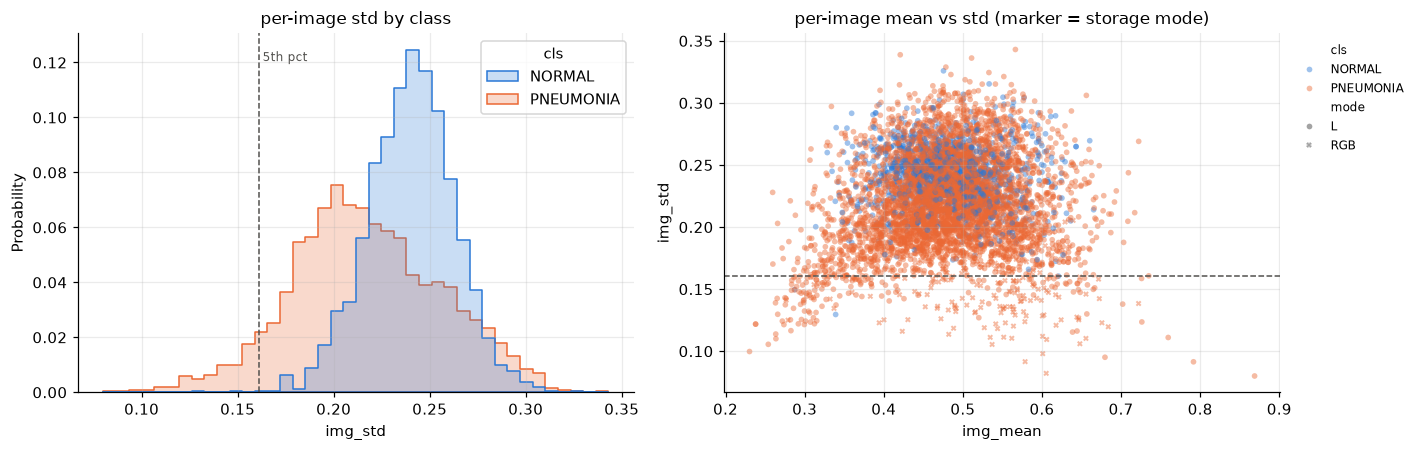

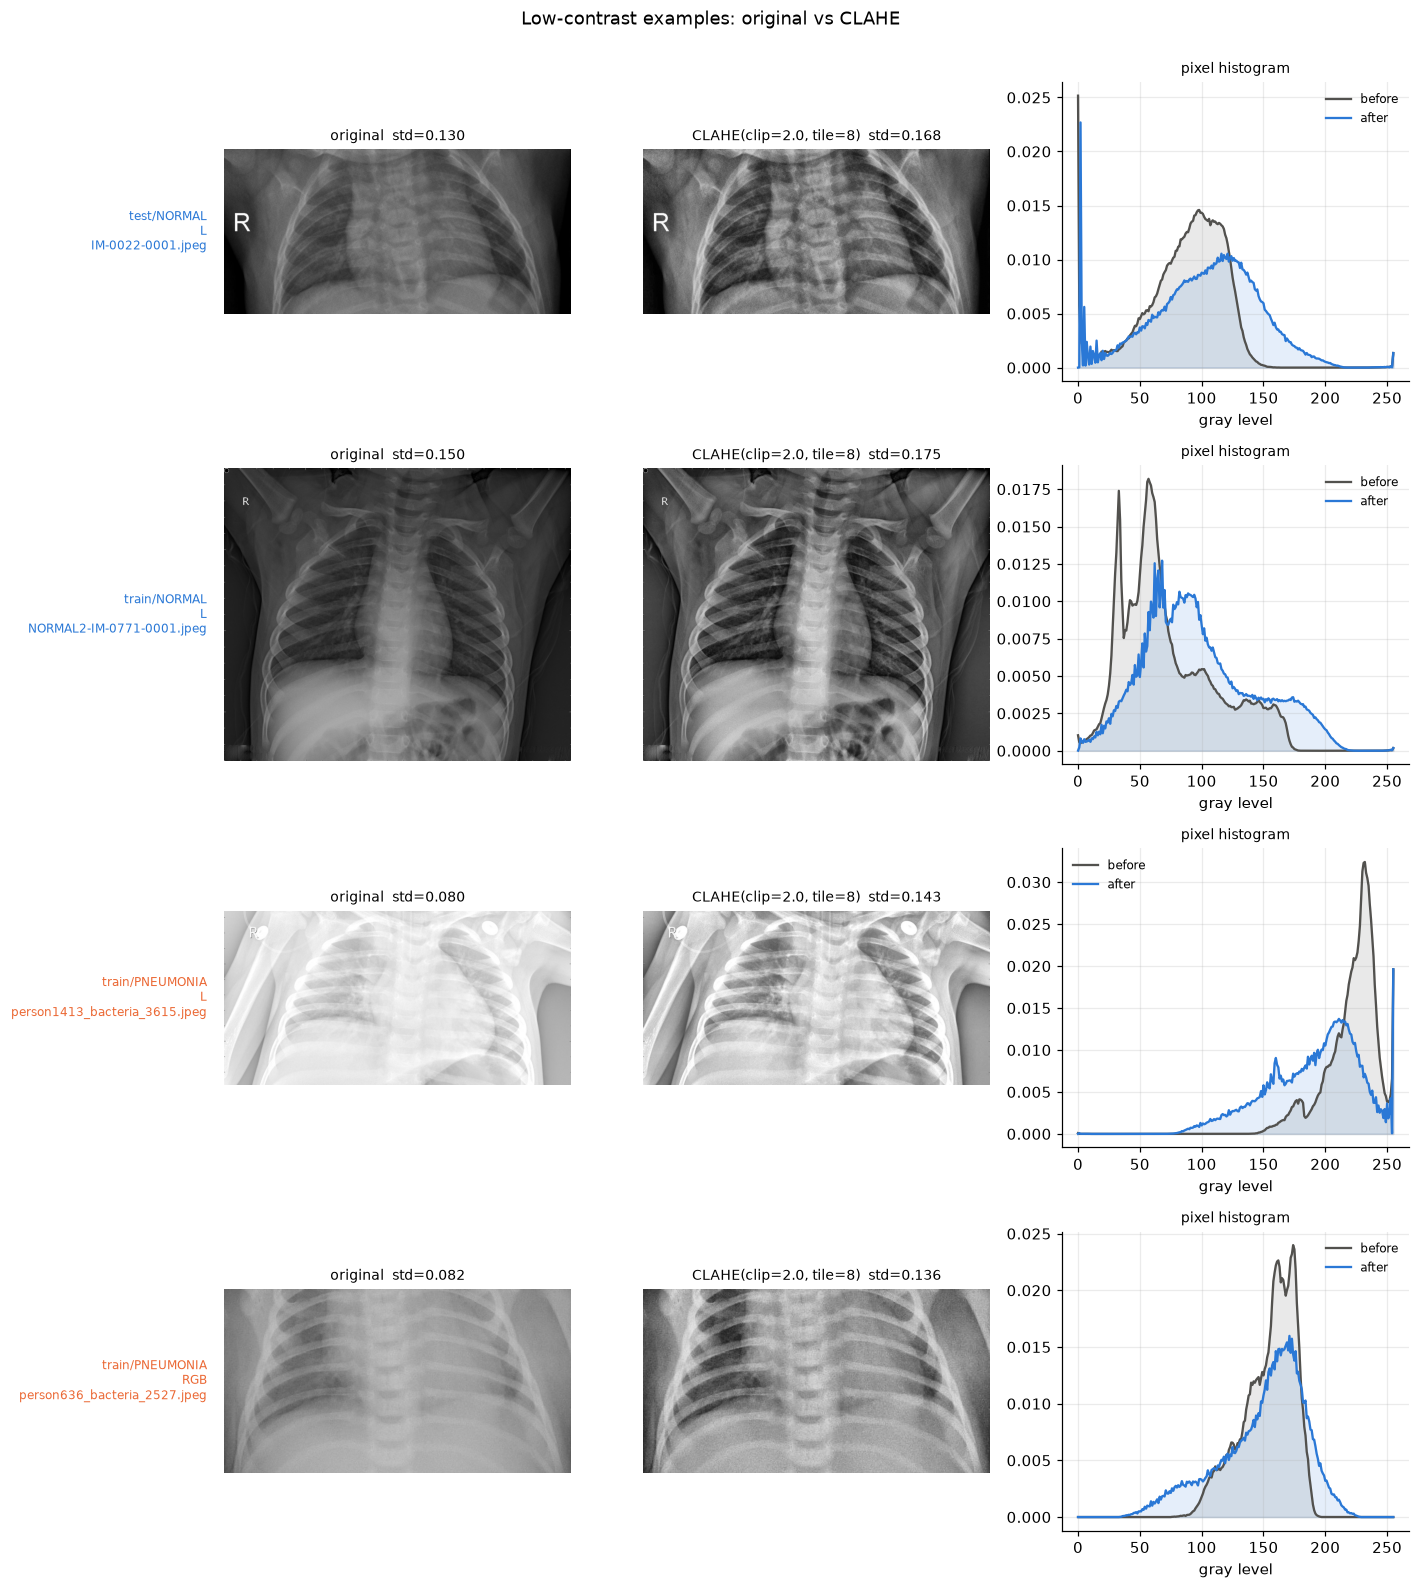

std_before        std_after       
                             median    std    median    std
cls                                                        
NORMAL                        0.241  0.022     0.250  0.017
PNEUMONIA                     0.215  0.039     0.226  0.034
gap (PNEUMONIA - NORMAL)     -0.026    NaN    -0.024    NaN

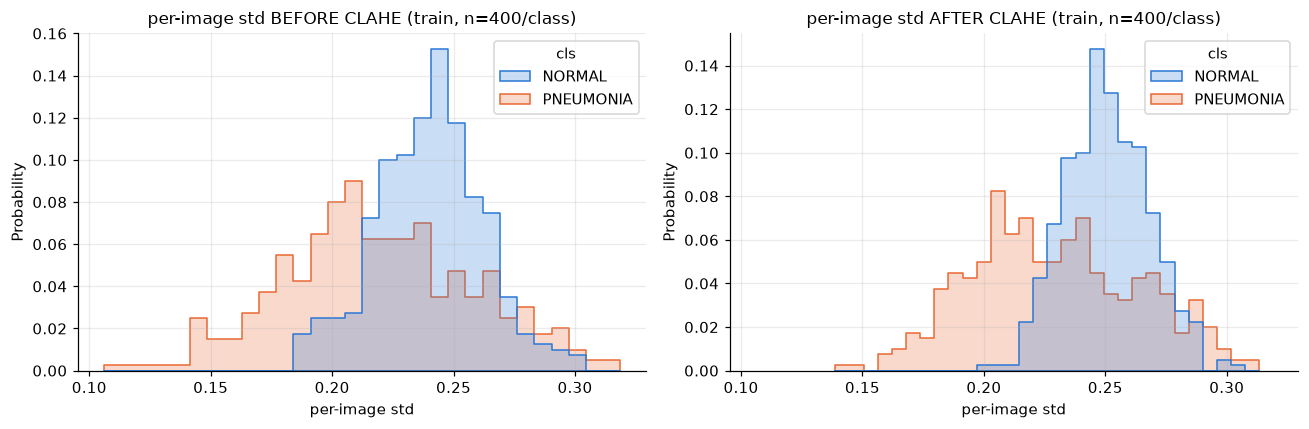

In [24]:
try:
    import cv2
except ImportError as e:  # Colab에는 기본 설치. 로컬은 pip install opencv-python-headless
    raise ImportError("CLAHE에는 OpenCV가 필요합니다: pip install opencv-python-headless") from e

# ---------- [표 1] 클래스별 이미지 단위 mean/std 요약 ----------
display(meta.groupby("cls", observed=True)[["img_mean", "img_std"]]
        .describe(percentiles=[0.05, 0.5, 0.95]).round(3).T)

# ---------- [표 2] 저대비 이미지(std 하위 5%)가 어디에 몰려 있는가 ----------
low_q = meta["img_std"].quantile(0.05)
meta["is_low"] = meta["img_std"] <= low_q
meta["group"] = np.where(meta["cls"] == "NORMAL", "NORMAL", "PNEUMONIA/" + meta["pneu_type"].astype(str))
print(f"low-contrast = std <= 5th pct ({low_q:.3f}): {meta['is_low'].sum()} images")
display(meta[meta["is_low"]].groupby(["split", "cls"], observed=True).size().to_frame("n_low"))

# ---------- [표 3] 세부 유형 × 저장 모드별 std: 신호(병변)와 편향(획득 경로)을 분리해서 본다 ----------
display(meta.groupby(["group", "mode"]).agg(n=("img_std", "size"),
                                            std_median=("img_std", "median"),
                                            mean_median=("img_mean", "median"),
                                            n_low=("is_low", "sum"),
                                            low_rate=("is_low", "mean")).round(3))

# ---------- [장표 1] std 분포(클래스별) + mean vs std 산점도(저장 모드별 마커) ----------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
sns.histplot(data=meta, x="img_std", hue="cls", hue_order=CLASSES, palette=CLASS_COLORS,
             element="step", stat="probability", common_norm=False, bins=40, ax=axes[0], alpha=0.25)
axes[0].axvline(low_q, color="#52514e", ls="--", lw=1)
axes[0].text(low_q, axes[0].get_ylim()[1] * 0.95, " 5th pct", fontsize=8, color="#52514e", va="top")
axes[0].set_title("per-image std by class")
sns.scatterplot(data=meta, x="img_mean", y="img_std", hue="cls", hue_order=CLASSES, palette=CLASS_COLORS,
                style="mode", markers={"L": "o", "RGB": "X"}, s=14, alpha=0.45, linewidth=0, ax=axes[1])
axes[1].axhline(low_q, color="#52514e", ls="--", lw=1)
axes[1].set_title("per-image mean vs std (marker = storage mode)")
axes[1].legend(frameon=False, fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

# ---------- [장표 2] 저대비 이미지 CLAHE 전후 좌우 비교 ----------
CLAHE_CLIP, CLAHE_TILE = 2.0, (8, 8)
clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_TILE)
BEFORE_COLOR, AFTER_COLOR = "#52514e", "#2a78d6"


def load_gray(path) -> np.ndarray:
    with Image.open(path) as im:
        return np.asarray(im.convert("L"))


examples = pd.concat([meta[(meta["cls"] == c) & meta["is_low"]].nsmallest(2, "img_std") for c in CLASSES])
fig, axes = plt.subplots(len(examples), 3, figsize=(13, 3.6 * len(examples)), squeeze=False)
for r, row in enumerate(examples.itertuples()):
    before = load_gray(row.path)
    after = clahe.apply(before)
    axes[r][0].imshow(before, cmap="gray", vmin=0, vmax=255)
    axes[r][0].set_title(f"original  std={before.std() / 255:.3f}", fontsize=9)
    axes[r][1].imshow(after, cmap="gray", vmin=0, vmax=255)
    axes[r][1].set_title(f"CLAHE(clip={CLAHE_CLIP}, tile={CLAHE_TILE[0]})  std={after.std() / 255:.3f}", fontsize=9)
    for ax in axes[r][:2]:
        ax.axis("off")
    for arr, color, name in [(before, BEFORE_COLOR, "before"), (after, AFTER_COLOR, "after")]:
        h = np.bincount(arr.ravel(), minlength=256) / arr.size
        axes[r][2].plot(np.arange(256), h, color=color, lw=1.5, label=name)
        axes[r][2].fill_between(np.arange(256), h, color=color, alpha=0.12)
    axes[r][2].set_title("pixel histogram", fontsize=9)
    axes[r][2].set_xlabel("gray level")
    axes[r][2].legend(frameon=False, fontsize=8)
    axes[r][0].text(-0.05, 0.5, f"{row.split}/{row.cls}\n{row.mode}\n{row.filename}", transform=axes[r][0].transAxes,
                    ha="right", va="center", fontsize=8, color=CLASS_COLORS[row.cls])
plt.suptitle("Low-contrast examples: original vs CLAHE", y=1.0)
plt.tight_layout()
plt.show()

# ---------- [표 4] + [장표 3] CLAHE 전후 이미지별 std (train, 클래스당 N_CLAHE장 샘플) ----------
N_CLAHE = 400
rows = []
for c in CLASSES:
    sub = meta[(meta["split"] == "train") & (meta["cls"] == c)].sample(n=N_CLAHE, random_state=SEED)
    for row in sub.itertuples():
        before = load_gray(row.path)
        after = clahe.apply(before)
        rows.append({"cls": c, "std_before": before.std() / 255, "std_after": after.std() / 255})
clahe_df = pd.DataFrame(rows)
clahe_df["cls"] = pd.Categorical(clahe_df["cls"], CLASSES, ordered=True)

summary = clahe_df.groupby("cls", observed=True)[["std_before", "std_after"]].agg(["median", "std"]).round(3)
med = clahe_df.groupby("cls", observed=True)[["std_before", "std_after"]].median()
summary.loc["gap (PNEUMONIA - NORMAL)", [("std_before", "median"), ("std_after", "median")]] = \
    (med.loc["PNEUMONIA"] - med.loc["NORMAL"]).round(3).values
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for ax, col, title in zip(axes, ["std_before", "std_after"], ["per-image std BEFORE CLAHE", "per-image std AFTER CLAHE"]):
    sns.histplot(data=clahe_df, x=col, hue="cls", hue_order=CLASSES, palette=CLASS_COLORS,
                 element="step", stat="probability", common_norm=False, bins=30, ax=ax, alpha=0.25)
    ax.set_title(f"{title} (train, n={N_CLAHE}/class)")
    ax.set_xlabel("per-image std")
plt.tight_layout()
plt.show()

## 3-6. Resize·채널 통일 전략별 변환 예시
- 활용 도표: 원본 | 224×224 늘리기(squash) | 짧은 변 224 후 center crop | 비율 유지 padding(letterbox) 좌우 비교 + RGB→L 변환 전후
- 판단 포인트: squash는 왜곡, crop은 폐 가장자리 손실, padding은 유효 해상도 손실. 어느 trade-off를 택할지 정한다.
- 구현 포인트: RGB -> L 변환은 im.convert("L")을 사용한다. im.split()[0]을 사용하지 않는다. 
    - 근거: 이 데이터셋은 RGB 채널이 모두 같은 픽셀을 갖고있음을 확인했기 때문에 im.split()[0]으로 더 정확하게 엄밀으로 변환하는 게 좋을 수 있다. 하지만 이 모델에 완전히 새로 들어오는 RGB 채널을 갖고있는 데이터도 세 채널이 모두 같은 값이라고 보장할 수는 없다. im.convert("L")은 RGB 채널을 평균적인 가중치로 뭉개주기 때문에 특정 하나의 채널에만 치우치지 않는 안정적인 흑백 이미지를 만들어준다. 
- **분석 결과**
    - squash resize: 우리는 종횡비가 다양한 사진을 쓰기 때문에, 단순 Squash resize는 이미지에 왜곡을 준다. 따라서 사용하면 안된다. 
    - 짧은 변 224 crop: 세로로 긴 사진은 폐의 모든 영역이 고루 crop된다. 하지만 가로로 긴 사진은 폐 가장자리의 정보가 심하게 소실되는 경향이 있다. 
    - 비율 유지 padding: 주변이 검정색으로 채워지는 방식으로, 가장 손해가 적을 것으로 보인다. 어차피 x-ray는 가장자리가 검정색이므로. 하지만 L/R 마커나 심전도 선과 같은 노이즈가 그대로 남는다. 

    - **결론:** 비율 유지 padding을 사용한다. L/R 마커는 거의 모든 데이터 사진에 존재하고 있고, 심전도 선은 그 수가 많지 않다. 
    - 그리고 U-Net으로 폐 영역 segmentation으로 먼저 crop한 뒤에 파이프라인을 시작하는 방식을 추가 실험으로 편성한다.

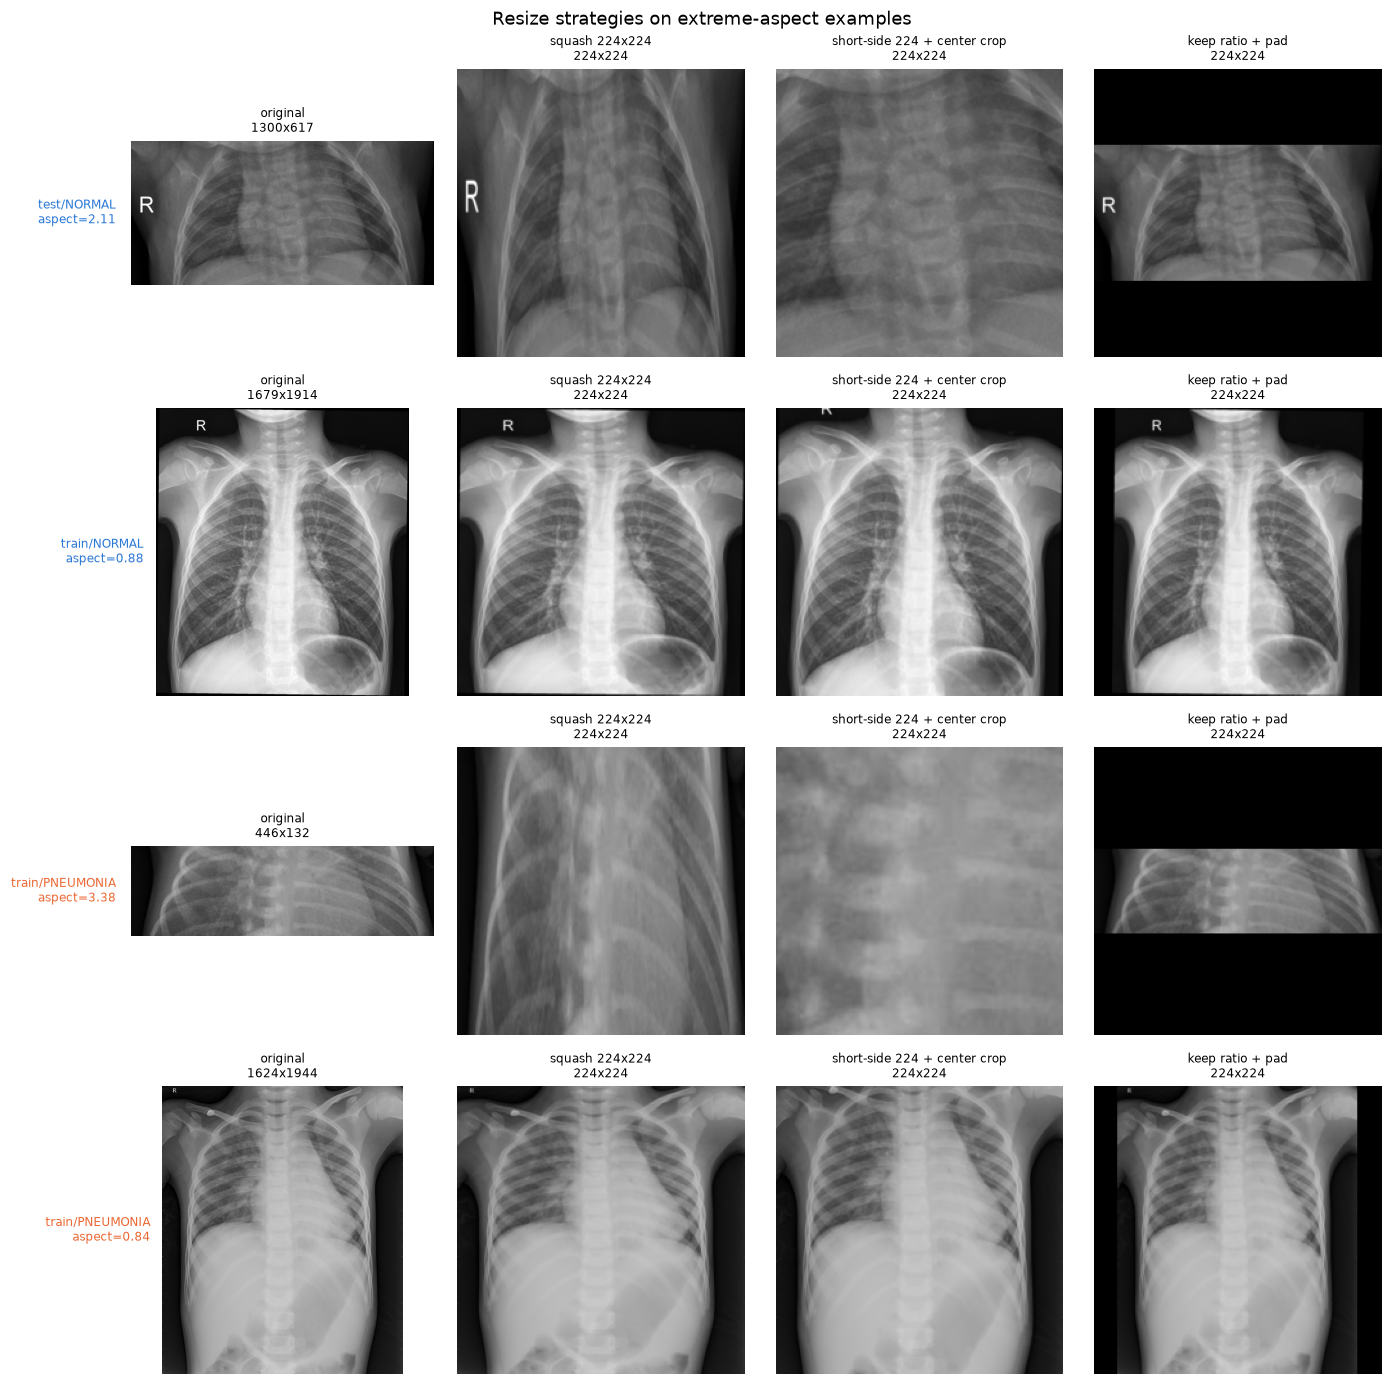

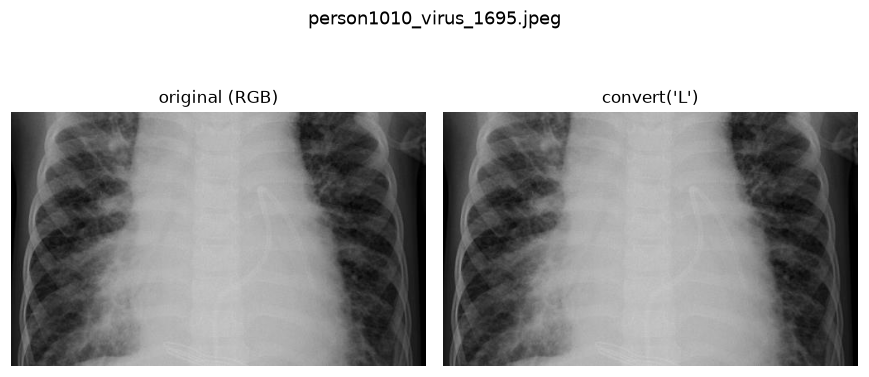

In [25]:
def resize_squash(im):
    return im.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)


def resize_center_crop(im):
    w, h = im.size
    s = IMG_SIZE / min(w, h)
    im2 = im.resize((max(IMG_SIZE, round(w * s)), max(IMG_SIZE, round(h * s))), Image.BILINEAR)
    l, t = (im2.width - IMG_SIZE) // 2, (im2.height - IMG_SIZE) // 2
    return im2.crop((l, t, l + IMG_SIZE, t + IMG_SIZE))


def resize_pad(im):
    w, h = im.size
    s = IMG_SIZE / max(w, h)
    im2 = im.resize((max(1, round(w * s)), max(1, round(h * s))), Image.BILINEAR)
    canvas = Image.new("L", (IMG_SIZE, IMG_SIZE), 0)
    canvas.paste(im2, ((IMG_SIZE - im2.width) // 2, (IMG_SIZE - im2.height) // 2))
    return canvas


STRATEGIES = [("original", lambda im: im), ("squash 224x224", resize_squash),
              ("short-side 224 + center crop", resize_center_crop), ("keep ratio + pad", resize_pad)]

examples = []
for cls in CLASSES:
    sub = meta[meta["cls"] == cls]
    examples.append(sub.loc[sub["aspect"].idxmax()])   # 가장 가로로 긴 이미지 (왜곡이 가장 큼)
    examples.append(sub.loc[sub["aspect"].idxmin()])   # 가장 세로로 긴 이미지

fig, axes = plt.subplots(len(examples), len(STRATEGIES), figsize=(3.2 * len(STRATEGIES), 3.2 * len(examples)))
for r, row in enumerate(examples):
    with Image.open(row["path"]) as im:
        gray = im.convert("L")
        for c, (name, fn) in enumerate(STRATEGIES):
            out = fn(gray)
            axes[r][c].imshow(out, cmap="gray", vmin=0, vmax=255)
            axes[r][c].set_title(f"{name}\n{out.width}x{out.height}", fontsize=8)
            axes[r][c].axis("off")
    axes[r][0].text(-0.05, 0.5, f"{row['split']}/{row['cls']}\naspect={row['aspect']:.2f}",
                    transform=axes[r][0].transAxes, ha="right", va="center", fontsize=8, color=CLASS_COLORS[row["cls"]])
plt.suptitle("Resize strategies on extreme-aspect examples")
plt.tight_layout()
plt.show()

# RGB -> L 변환 전후 (RGB 이미지가 있을 때만)
rgb = meta[meta["n_channels"] == 3]
if len(rgb):
    ex = rgb.iloc[0]
    with Image.open(ex["path"]) as im:
        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(im)
        axes[0].set_title(f"original ({im.mode})")
        axes[1].imshow(im.convert("L"), cmap="gray", vmin=0, vmax=255)
        axes[1].set_title("convert('L')")
        for ax in axes:
            ax.axis("off")
        plt.suptitle(ex["filename"])
        plt.tight_layout()
        plt.show()


## 4-1. 클래스별 픽셀 밝기 분포
- 활용 도표: 픽셀 단위 밝기 Histogram 오버레이(전체 픽셀 집계) + 이미지별 mean Boxplot(x=클래스, hue=split) + 클래스별 평균 이미지와 차이맵
- 판단 포인트: 분포가 쌍봉인지(배경 검정·뼈 밝음), 클래스 간 차이가 밝기 자체에서 오는지, 평균 이미지에 위치 편향이 있는지 확인한다.

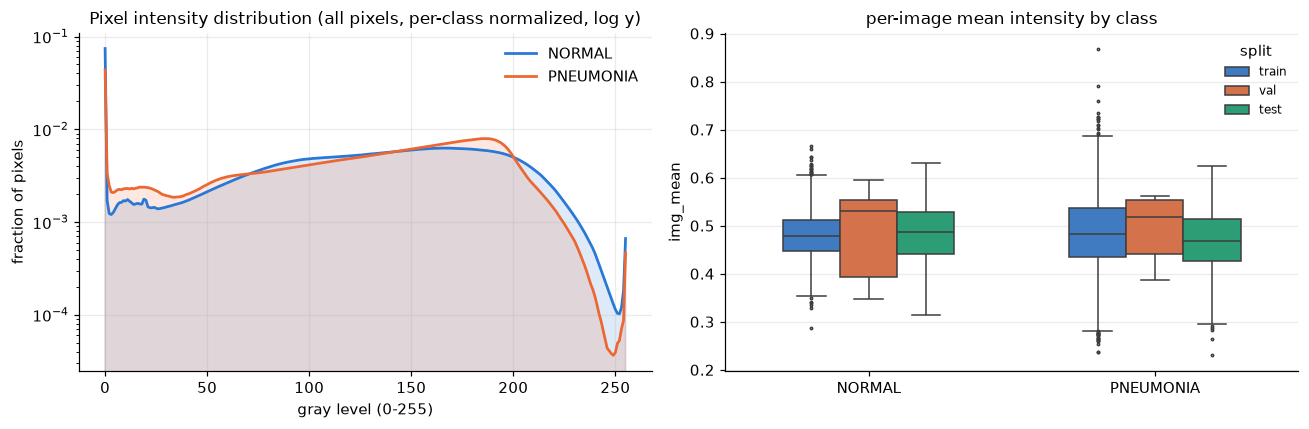

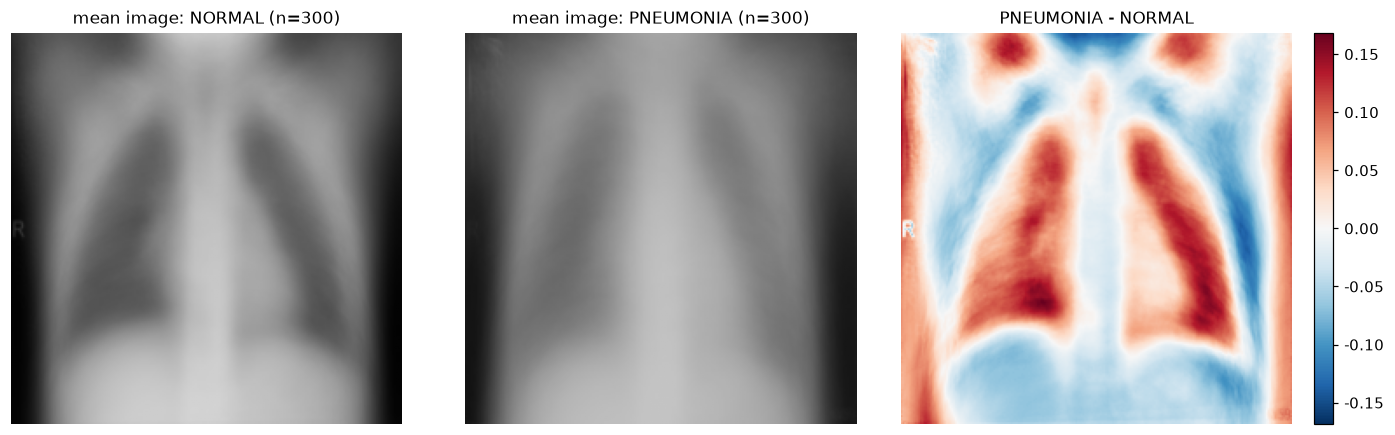

In [14]:
bins = np.arange(256)
class_hist = {c: sum(PIX_HIST[f"{s}/{c}"] for s in SPLITS) for c in CLASSES}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for c in CLASSES:
    h = class_hist[c] / class_hist[c].sum()
    axes[0].plot(bins, h, color=CLASS_COLORS[c], lw=1.8, label=c)
    axes[0].fill_between(bins, h, color=CLASS_COLORS[c], alpha=0.15)
axes[0].set_yscale("log")
axes[0].set_title("Pixel intensity distribution (all pixels, per-class normalized, log y)")
axes[0].set_xlabel("gray level (0-255)")
axes[0].set_ylabel("fraction of pixels")
axes[0].legend(frameon=False)

sns.boxplot(data=meta, x="cls", y="img_mean", hue="split", order=CLASSES, hue_order=SPLITS,
            palette=SPLIT_COLORS, width=0.6, fliersize=1.5, linewidth=1, ax=axes[1])
axes[1].set_title("per-image mean intensity by class")
axes[1].set_xlabel("")
axes[1].legend(title="split", frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

# 클래스별 평균 이미지 (train, 클래스당 N_MEAN장 샘플, squash 224 후 평균)
N_MEAN = 300
mean_imgs = {}
for c in CLASSES:
    sub = meta[(meta["split"] == "train") & (meta["cls"] == c)].sample(n=N_MEAN, random_state=SEED)
    acc = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float64)
    for p in sub["path"]:
        with Image.open(p) as im:
            acc += np.asarray(resize_squash(im.convert("L")), dtype=np.float64)
    mean_imgs[c] = acc / N_MEAN / 255.0

diff = mean_imgs["PNEUMONIA"] - mean_imgs["NORMAL"]
lim = np.abs(diff).max()
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, c in zip(axes[:2], CLASSES):
    ax.imshow(mean_imgs[c], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"mean image: {c} (n={N_MEAN})")
im_ = axes[2].imshow(diff, cmap="RdBu_r", vmin=-lim, vmax=lim)
axes[2].set_title("PNEUMONIA - NORMAL")
plt.colorbar(im_, ax=axes[2], fraction=0.046)
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


## 4-2. 데이터셋 통계 vs ImageNet 통계
- 활용 도표: 비교 DataFrame + 실제 픽셀 Histogram 위에 두 통계의 mean 수직선·±std 음영 오버레이 + 두 정규화 적용 후 값 분포 비교
- 판단 포인트: 분포가 정규분포가 아니므로 Bell curve로 그리지 않는다. 정규화 후 값의 중심이 0 근처에 오는지, 범위가 어떻게 달라지는지 본다.

- **분석 결과:**
    - [장표(좌)] 학습 대상 데이터셋의 밝기 평균이 더 밝은 편이다. 
    - [장표(우)] 원본 이미지의 픽셀 분포를 ImageNet 기준으로 정규화하면 분포가 약간 +0.17 밝은 쪽으로 치우친다. 
    - **결론: 차이가 작다. ImageNet 통계를 기준으로 정규화 후에 평균은 0.17, 표준편차는 1.09로, 데이터셋 통계 기준으로 정규화를 했을 때와 별 차이가 나지 않는다. 어떤 거로 정규화해도 영향이 없을 것으로 판단된다. 따라서 사전학습 가중치와의 일관성을 고려해서 ImageNet 통계를 기준으로 정규화하는 것으로 결정한다.**

,mean,std
"dataset (train, gray)",0.4875,0.2456
"dataset (all, gray)",0.4874,0.2454
ImageNet (RGB avg),0.4490,0.2260
ImageNet R,0.4850,0.2290
ImageNet G,0.4560,0.2240
ImageNet B,0.4060,0.2250


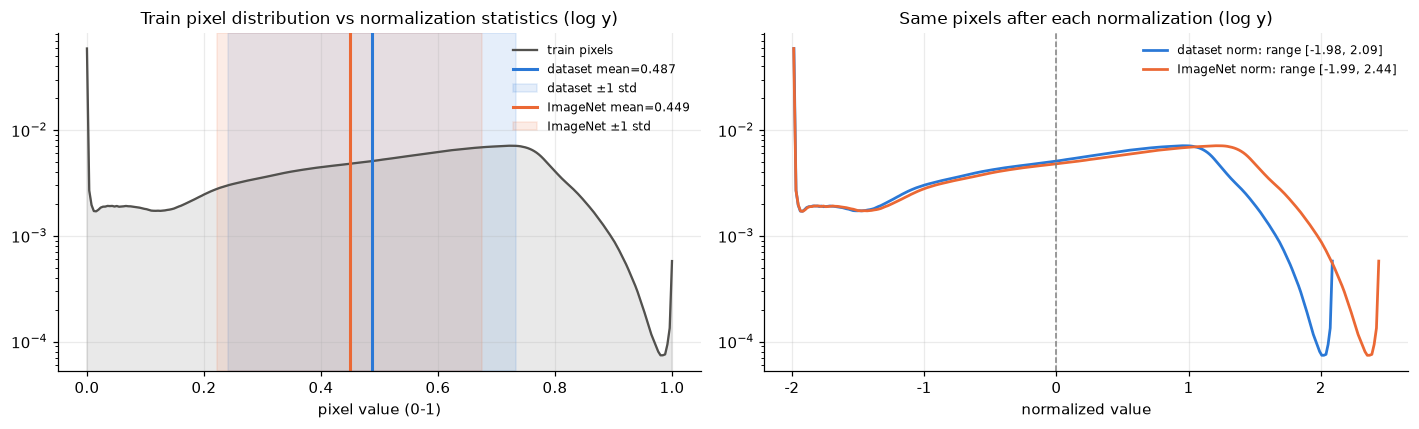

In [15]:
total_hist = sum(PIX_HIST[f"{s}/{c}"] for s in SPLITS for c in CLASSES)
train_hist = sum(PIX_HIST[f"train/{c}"] for c in CLASSES)
levels = np.arange(256) / 255.0


def hist_stats(h):
    p = h / h.sum()
    m = float((levels * p).sum())
    sd = float(np.sqrt(((levels - m) ** 2 * p).sum()))
    return m, sd


ds_mean, ds_std = hist_stats(train_hist)          # 정규화 통계는 train으로만 산출
all_mean, all_std = hist_stats(total_hist)
im_gray_mean, im_gray_std = float(IMAGENET_MEAN.mean()), float(IMAGENET_STD.mean())

stats = pd.DataFrame({
    "mean": [ds_mean, all_mean, im_gray_mean, *IMAGENET_MEAN],
    "std": [ds_std, all_std, im_gray_std, *IMAGENET_STD],
}, index=["dataset (train, gray)", "dataset (all, gray)", "ImageNet (RGB avg)", "ImageNet R", "ImageNet G", "ImageNet B"]).round(4)
display(stats)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
p = train_hist / train_hist.sum()
axes[0].plot(levels, p, color="#52514e", lw=1.5, label="train pixels")
axes[0].fill_between(levels, p, color="#52514e", alpha=0.12)
for (m, sd, name, color) in [(ds_mean, ds_std, "dataset", "#2a78d6"), (im_gray_mean, im_gray_std, "ImageNet", "#eb6834")]:
    axes[0].axvline(m, color=color, lw=2, label=f"{name} mean={m:.3f}")
    axes[0].axvspan(m - sd, m + sd, color=color, alpha=0.12, label=f"{name} ±1 std")
axes[0].set_yscale("log")
axes[0].set_title("Train pixel distribution vs normalization statistics (log y)")
axes[0].set_xlabel("pixel value (0-1)")
axes[0].legend(frameon=False, fontsize=8)

for (m, sd, name, color) in [(ds_mean, ds_std, "dataset norm", "#2a78d6"), (im_gray_mean, im_gray_std, "ImageNet norm", "#eb6834")]:
    z = (levels - m) / sd
    axes[1].plot(z, p, color=color, lw=1.8, label=f"{name}: range [{z.min():.2f}, {z.max():.2f}]")
axes[1].axvline(0, color="gray", lw=1, ls="--")
axes[1].set_yscale("log")
axes[1].set_title("Same pixels after each normalization (log y)")
axes[1].set_xlabel("normalized value")
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()


## 5-1. 해시 기준 완전 중복 이미지
- 활용 도표: 3×3 Heatmap(split × split 중복 쌍 수) + 중복 그룹 DataFrame + 중복 쌍 좌우 비교
- 판단 포인트: split 간 중복은 누수(제거 필수), split 내 중복은 단순 중복(test 내에서는 제거). 클래스가 다른 중복은 라벨 오류 후보다.

- **분석 결과**
    - split 간 중복은 없다. 즉, 데이터 누수는 없다. 
    - train set 내 중복은 단순한 중복이다. 전체 데이터 개수를 기준으로 봤을 때, 28장만 중복이라는 것은 영향이 없을 것으로 판단된다. 에폭 몇 번 더 돈 셈이다. 
    - test set 내 중복은 하나만 남기고 제거해야 한다. 같은 문제가 6개인 시험지를 푸는 것과 같은 것이기 때문이다. 성능 지표가 오염될 수 있다. 

duplicate groups: 30, images involved: 62 / 5856
pairs with different class labels: 0


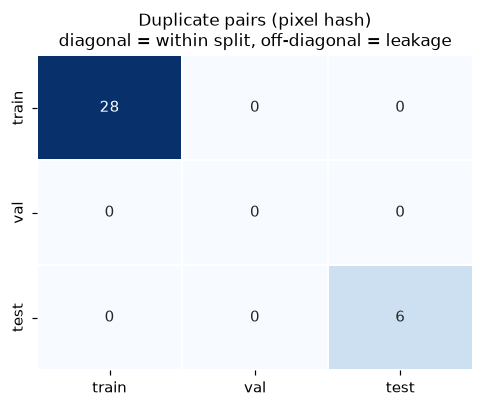

,n,splits,classes,files
pixel_md5,,,,
22daea818cb403406df02e2794e5a8c5,3,train,PNEUMONIA,person1372_bacteria_3501.jpeg | person1372_bac...
3842226067bcc7b2c30d5bf3071caf58,3,train,PNEUMONIA,person258_bacteria_1207.jpeg | person258_bacte...
0cbe24df390e1c8b171e9d334e2bcfdd,2,train,PNEUMONIA,person1349_bacteria_3436.jpeg | person1349_bac...
6cd694a503936fb217d1020b062788a6,2,train,PNEUMONIA,person401_virus_797.jpeg | person401_virus_798...
dad4660b01dfa9c5961bfcaa0168a32b,2,train,PNEUMONIA,person266_bacteria_1237.jpeg | person266_bacte...
cfa6ca7af6a548d811b06dd0c375c923,2,train,PNEUMONIA,person162_virus_321.jpeg | person162_virus_322...
bec755496f6548780a14f09d51d6f68f,2,train,PNEUMONIA,person1159_virus_1944.jpeg | person1159_virus_...
bcd47182e622a00b47ca8a483736af8c,2,test,NORMAL,NORMAL2-IM-0173-0001-0001.jpeg | NORMAL2-IM-01...
ba262d1d8af8c56a91526c9877e17f8c,2,train,PNEUMONIA,person688_virus_1281.jpeg | person688_virus_12...


groups spanning multiple splits: 0


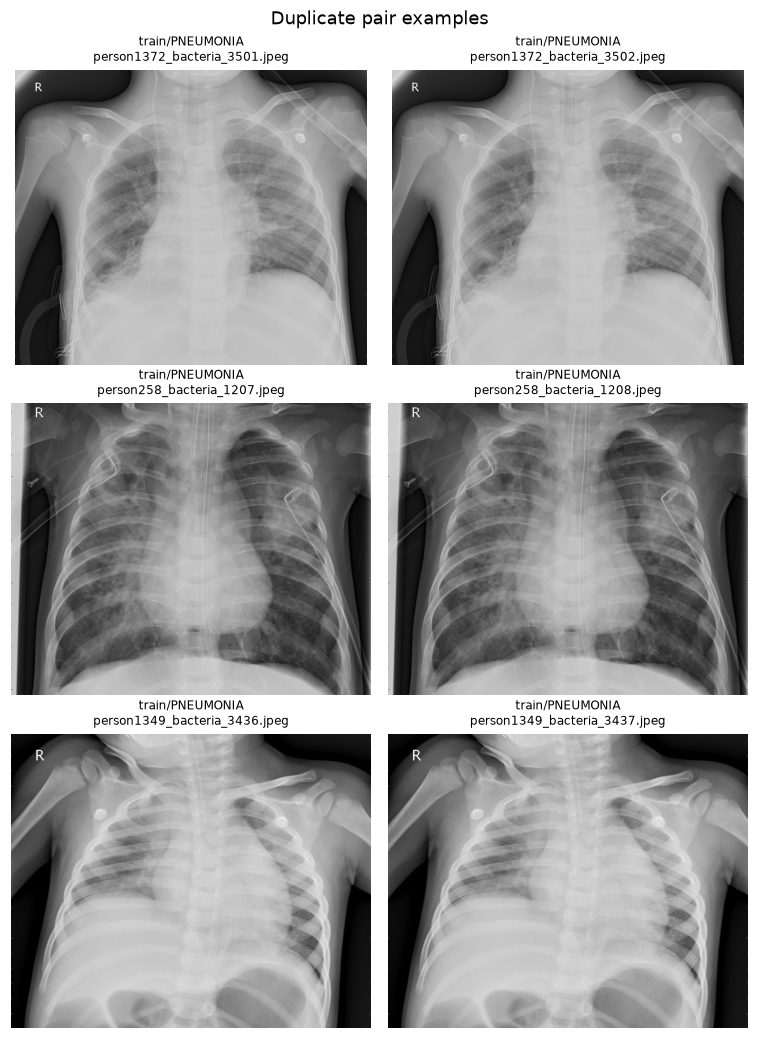

In [16]:
from itertools import combinations

HASH_COL = "pixel_md5"   # 픽셀 기준. 파일 바이트 기준으로 보려면 "file_md5"
dup = meta[meta.duplicated(HASH_COL, keep=False)].sort_values([HASH_COL, "split"])
groups = dup.groupby(HASH_COL)
print(f"duplicate groups: {groups.ngroups}, images involved: {len(dup)} / {len(meta)}")

pair_mat = pd.DataFrame(0, index=SPLITS, columns=SPLITS)
cross_class = 0
for _, g in groups:
    for a, b in combinations(g.itertuples(), 2):
        s1, s2 = sorted([a.split, b.split], key=SPLITS.index)
        pair_mat.loc[s1, s2] += 1
        cross_class += int(a.cls != b.cls)
print(f"pairs with different class labels: {cross_class}")

fig, ax = plt.subplots(figsize=(4.5, 3.8))
sns.heatmap(pair_mat, annot=True, fmt="d", cmap=SEQ_CMAP, cbar=False, linewidths=1, linecolor="white", ax=ax)
ax.set_title("Duplicate pairs (pixel hash)\ndiagonal = within split, off-diagonal = leakage")
ax.grid(False)
plt.tight_layout()
plt.show()

summary = (groups.agg(n=("path", "size"),
                      splits=("split", lambda s: ",".join(sorted(set(s), key=SPLITS.index))),
                      classes=("cls", lambda s: ",".join(sorted(set(s)))),
                      files=("filename", lambda s: " | ".join(s)))
           .sort_values("n", ascending=False))
display(summary.head(20))

cross = summary[summary["splits"].str.contains(",")]
print(f"groups spanning multiple splits: {len(cross)}")

# 예시: 최대 3개 그룹의 앞 2장 좌우 비교
show = pd.concat([cross, summary]).drop_duplicates().head(3)
if len(show):
    fig, axes = plt.subplots(len(show), 2, figsize=(7, 3.2 * len(show)), squeeze=False)
    for r, (h, _) in enumerate(show.iterrows()):
        g = dup[dup[HASH_COL] == h].head(2)
        for c, row in enumerate(g.itertuples()):
            with Image.open(row.path) as im:
                axes[r][c].imshow(im.convert("L"), cmap="gray", vmin=0, vmax=255)
            axes[r][c].set_title(f"{row.split}/{row.cls}\n{row.filename}", fontsize=8)
            axes[r][c].axis("off")
    plt.suptitle("Duplicate pair examples")
    plt.tight_layout()
    plt.show()


## 6-1. train 내 사람별 이미지 수 분포
- 활용 도표: Bar chart(x=한 사람당 이미지 수, y=사람 수) + 상위 N명 DataFrame(bacteria/virus 내역)
- 판단 포인트: 한 사람의 이미지가 여러 장이면 재분할 시 person 단위 그룹 분할이 필요하다.

- **분석 결과**
    - 한 사람이 최대 30장까지 찍은 경우가 있다.
    - train+val으로 다시 train/val split을 진행할 것이므로, 이 때 한 사람의 사진이 두 split에 동시에 들어가지 않도록 person 단위 그룹 분할이 필요하다. 

train PNEUMONIA: 3875 images, 1635 unique person ids, mean 2.37 images/person, max 30


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,16,18,30
n_persons,630,561,191,85,43,44,29,19,12,6,5,4,1,2,1,1,1


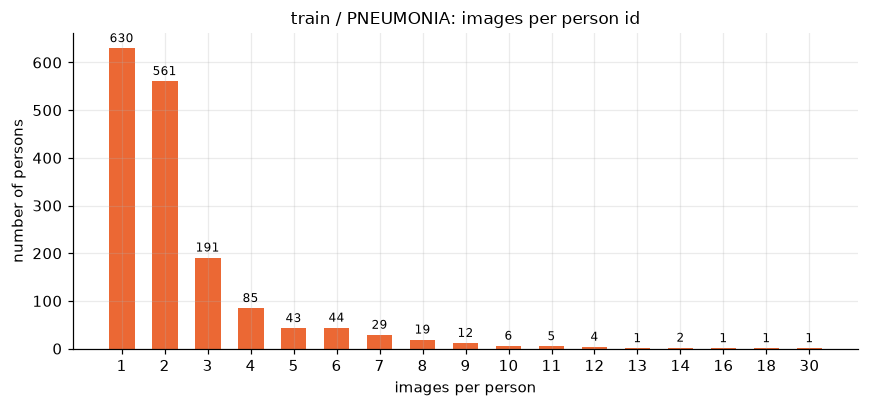

,n,bacteria,virus,files
person_id,,,,
23,30,30,0,person23_bacteria_100.jpeg | person23_bacteria...
441,18,14,4,person441_bacteria_1900.jpeg | person441_bacte...
124,16,0,16,person124_virus_231.jpeg | person124_virus_233...
30,14,14,0,person30_bacteria_145.jpeg | person30_bacteria...
1320,14,13,1,person1320_bacteria_3339.jpeg | person1320_bac...
348,13,4,9,person348_bacteria_1601.jpeg | person348_bacte...
1411,12,11,1,person1411_bacteria_3591.jpeg | person1411_bac...
266,12,11,1,person266_bacteria_1237.jpeg | person266_bacte...
326,12,5,7,person326_bacteria_1503.jpeg | person326_bacte...


In [27]:
pneu_train = meta[(meta["split"] == "train") & meta["person_id"].notna()].copy()
pneu_train["person_id"] = pneu_train["person_id"].astype(int)
per_person = pneu_train.groupby("person_id").size()
count_of_counts = per_person.value_counts().sort_index()

print(f"train PNEUMONIA: {len(pneu_train)} images, {per_person.size} unique person ids, "
      f"mean {per_person.mean():.2f} images/person, max {per_person.max()}")
display(count_of_counts.to_frame("n_persons").T)

fig, ax = plt.subplots(figsize=(8, 3.8))
bars = ax.bar(count_of_counts.index.astype(str), count_of_counts.values, color=CLASS_COLORS["PNEUMONIA"], width=0.6)
ax.bar_label(bars, padding=2, fontsize=8)
ax.set_xlabel("images per person")
ax.set_ylabel("number of persons")
ax.set_title("train / PNEUMONIA: images per person id")
plt.tight_layout()
plt.show()

top = (pneu_train.groupby("person_id")
       .agg(n=("path", "size"), bacteria=("pneu_type", lambda s: (s == "bacteria").sum()),
            virus=("pneu_type", lambda s: (s == "virus").sum()),
            files=("filename", lambda s: " | ".join(sorted(s))))
       .sort_values("n", ascending=False))
display(top.head(10))


## 6-2. 파일명 번호 체계와 split 간 독립성
- 활용 도표: 파일명 패턴 DataFrame(split × 클래스) + person id 교집합 DataFrame(split 쌍) + Strip plot(x=person id, y=split)
- 판단 포인트: NORMAL은 person 정보가 없다. PNEUMONIA person id가 split 간에 겹치면 동일 인물인지(5-1 해시 결과, 이미지 유사성)로 교차 확인한다.

- **분석 결과**
    1. person id는 세 split 모두 PNEUMONIA 클래스에만 있다.
    2. 같은 person id가 train과 test에 중복되어 170개가 존재한다. 
    3. 하지만 중복된 person id라 하더라도 서로 동일한 사진은 한 장도 없다. 따라서 같은 사람인지는 번호만으로 단정할 수 없다. **person id는 train/val split 시 고려 대상으로 넣지 않는다.**

n
split cls       pattern                      
train NORMAL    IM-#-#-#.jpeg              80
                IM-#-#.jpeg               517
                NORMAL#-IM-#-#-#.jpeg      53
                NORMAL#-IM-#-#.jpeg       691
      PNEUMONIA person#_bacteria_#.jpeg  2530
                person#_virus_#.jpeg     1344
                person#_virus_#_#.jpeg      1
val   NORMAL    NORMAL#-IM-#-#.jpeg         8
      PNEUMONIA person#_bacteria_#.jpeg     8
test  NORMAL    IM-#-#-#.jpeg               4
                IM-#-#.jpeg                65
                NORMAL#-IM-#-#-#.jpeg       6
                NORMAL#-IM-#-#.jpeg       159
      PNEUMONIA person#_bacteria_#.jpeg   242
                person#_virus_#.jpeg      148

NORMAL images with person id: 0


,train,val,test
unique ids,1635,7,202
min id,1,1946,1
max id,1945,1954,1685


person id intersection size (diagonal = unique ids in split)


,train,val,test
train,1635,0,170
val,0,7,0
test,170,0,202


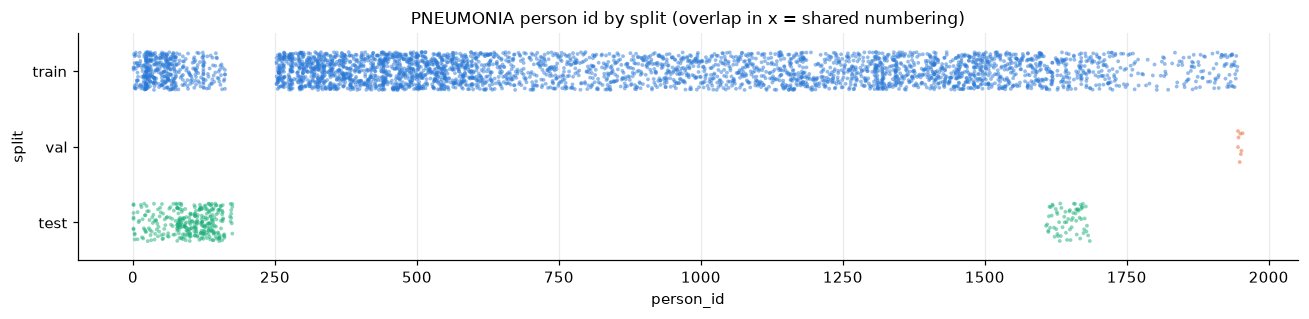

example shared person id=1 (same pixel_md5 across splits => real duplicate)


,split,cls,filename,width,height,pixel_md5
2967,train,PNEUMONIA,person1_bacteria_1.jpeg,712,439,c901b203e2751964e5c3b89e35326617
2968,train,PNEUMONIA,person1_bacteria_2.jpeg,1240,840,7f39f091cfb4237449423a515dd9e3a0
5719,test,PNEUMONIA,person1_virus_11.jpeg,872,560,2b8c531c86a4f2e37c76bb2979a593c9
5720,test,PNEUMONIA,person1_virus_12.jpeg,1080,624,e34eb39a3de95c14aba2440cac26b09f
5721,test,PNEUMONIA,person1_virus_13.jpeg,1136,654,ca0fb78af19ebfce1f9152261d7bdb5d
5722,test,PNEUMONIA,person1_virus_6.jpeg,944,640,97af9bb5486f4f0c5251438cca964d2a
5723,test,PNEUMONIA,person1_virus_7.jpeg,1000,544,a3f6886d7620627cedae843ce68dc21f
5724,test,PNEUMONIA,person1_virus_8.jpeg,960,544,a5f93650ed6a78dc4c70b57260089db9
5725,test,PNEUMONIA,person1_virus_9.jpeg,856,552,1b29e90e3bd3d7a5fd1783f0af93d51f


shared ids: 170; among them, ids with a pixel-identical image in both train and val/test: 0
=> 0이면 번호는 겹쳐도 같은 사진은 아니다. 같은 사람인지는 번호만으로 단정할 수 없다.


In [18]:
def name_pattern(name: str) -> str:
    return re.sub(r"\d+", "#", name)


pat = (meta.assign(pattern=meta["filename"].map(name_pattern))
       .groupby(["split", "cls", "pattern"], observed=True).size().to_frame("n"))
display(pat)
print("NORMAL images with person id:", int(meta[(meta["cls"] == "NORMAL")]["person_id"].notna().sum()))

pneu = meta[meta["person_id"].notna()].copy()
pneu["person_id"] = pneu["person_id"].astype(int)
ids = {s: set(pneu.loc[pneu["split"] == s, "person_id"]) for s in SPLITS}
rng_df = pd.DataFrame({s: [len(ids[s]), min(ids[s]) if ids[s] else None, max(ids[s]) if ids[s] else None]
                       for s in SPLITS}, index=["unique ids", "min id", "max id"])
display(rng_df)

inter = pd.DataFrame([[len(ids[a] & ids[b]) for b in SPLITS] for a in SPLITS], index=SPLITS, columns=SPLITS)
print("person id intersection size (diagonal = unique ids in split)")
display(inter)

fig, ax = plt.subplots(figsize=(12, 3))
sns.stripplot(data=pneu, x="person_id", y="split", order=SPLITS, hue="split", hue_order=SPLITS,
              palette=SPLIT_COLORS, size=2.5, alpha=0.5, jitter=0.25, legend=False, ax=ax)
ax.set_title("PNEUMONIA person id by split (overlap in x = shared numbering)")
plt.tight_layout()
plt.show()

# 겹치는 id가 있으면 예시 파일명과 픽셀 해시 일치 여부를 확인한다
shared = sorted(ids["train"] & (ids["test"] | ids["val"]))
if shared:
    ex_id = shared[0]
    ex = pneu[pneu["person_id"] == ex_id][["split", "cls", "filename", "width", "height", "pixel_md5"]]
    print(f"example shared person id={ex_id} (same pixel_md5 across splits => real duplicate)")
    display(ex)
    n_cross_dup = 0
    for pid in shared:
        g = pneu[pneu["person_id"] == pid]
        h_train = set(g.loc[g["split"] == "train", "pixel_md5"])
        h_other = set(g.loc[g["split"] != "train", "pixel_md5"])
        n_cross_dup += int(bool(h_train & h_other))
    print(f"shared ids: {len(shared)}; among them, ids with a pixel-identical image in both train and val/test: {n_cross_dup}")
    print("=> 0이면 번호는 겹쳐도 같은 사진은 아니다. 같은 사람인지는 번호만으로 단정할 수 없다.")
